In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/kartiksapkal/load-data/meal_info.csv
/kaggle/input/datasets/kartiksapkal/load-data/train1.csv


# AI-Powered Dynamic Pricing & Revenue Optimization

## Food Demand Forecasting Dataset (Kaggle)

**Goal:** Estimate price elasticity, predict demand, simulate prices, and recommend a price that maximizes expected revenue.

**Dataset:** https://www.kaggle.com/datasets/kannanaikkal/food-demand-forecasting
Columns used: `week`, `center_id`, `meal_id`, `checkout_price`, `base_price`, `emailer_for_promotion`, `homepage_featured`, `num_orders`.
Optional enrichment file `meal_info.csv` (columns: `meal_id`, `category`, `cuisine`) adds a product category.

### Project workflow
1. Load and understand data
2. Data cleaning
3. Feature engineering
4. Exploratory Data Analysis
5. Meal-level weekly aggregation
6. Price elasticity estimation
7. Demand prediction
8. Time-based model evaluation
9. Price simulation
10. Revenue optimization
11. Final pricing recommendations

> **Important:** This notebook treats the available data as observational data. Elasticity estimates show an observed relationship and should not automatically be interpreted as causal effects of changing price.


### Enhanced modeling note

This notebook includes the complete Step 5 improvement workflow: baseline metrics, Adjusted R², feature importance, residual analysis, tuned XGBoost, original-vs-tuned comparison, automatic best-model selection, and final selected-model metrics. No target value from the test period is used as a modeling feature.

## 1. Import Libraries

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import statsmodels.api as sm

%matplotlib inline
sns.set_theme(style="whitegrid")

## 2. Load Dataset

**How to get the data:**
1. Download `train.csv` (and optionally `meal_info.csv`) from
   https://www.kaggle.com/datasets/kannanaikkal/food-demand-forecasting
2. Upload both files to this notebook's working folder (or update `data_path` below).

Expected `train.csv` columns:
`id, week, center_id, meal_id, checkout_price, base_price, emailer_for_promotion, homepage_featured, num_orders`


In [3]:
data_path = "/kaggle/input/datasets/kartiksapkal/load-data/train1.csv"          # path to the downloaded Food Demand Forecasting train.csv
meal_info_path = "/kaggle/input/datasets/kartiksapkal/load-data/meal_info.csv"  # optional: adds a 'category' column

retail_price = pd.read_csv(data_path)

# Optional enrichment: bring in meal category if the file is available
try:
    meal_info = pd.read_csv(meal_info_path)
    retail_price = retail_price.merge(
        meal_info[["meal_id", "category"]],
        on="meal_id",
        how="left"
    )
    retail_price["category"] = retail_price["category"].fillna("Unknown")
except FileNotFoundError:
    print("meal_info.csv not found - continuing without a category column.")
    retail_price["category"] = "Unknown"

print("Shape:", retail_price.shape)
display(retail_price.head())


Shape: (456548, 10)


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,category
0,1379560,1,55,1885,136.83,152.29,0,0,177,Beverages
1,1466964,1,55,1993,136.83,135.83,0,0,270,Beverages
2,1346989,1,55,2539,134.86,135.86,0,0,189,Beverages
3,1338232,1,55,2139,339.50,437.53,0,0,54,Beverages
4,1448490,1,55,2631,243.50,242.50,0,0,40,Beverages


## 3. Data Quality Check

In [4]:
print("Data types:")
display(retail_price.dtypes)

print("\nMissing values:")
display(retail_price.isnull().sum())

print("\nDuplicate rows:", retail_price.duplicated().sum())

print("\nSummary statistics:")
display(retail_price.describe(include="all").T)

Data types:


id                         int64
week                       int64
center_id                  int64
meal_id                    int64
checkout_price           float64
base_price               float64
emailer_for_promotion      int64
homepage_featured          int64
num_orders                 int64
category                  object
dtype: object


Missing values:


id                       0
week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
num_orders               0
category                 0
dtype: int64


Duplicate rows: 0

Summary statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,456548.0,NaN,NaN,NaN,1250096.305633,144354.822378,1000000.0,1124998.75,1250183.5,1375140.25,1499999.0
week,456548.0,NaN,NaN,NaN,74.768771,41.524956,1.0,39.0,76.0,111.0,145.0
center_id,456548.0,NaN,NaN,NaN,82.105796,45.975046,10.0,43.0,76.0,110.0,186.0
meal_id,456548.0,NaN,NaN,NaN,2024.337458,547.42092,1062.0,1558.0,1993.0,2539.0,2956.0
checkout_price,456548.0,NaN,NaN,NaN,332.238933,152.939723,2.97,228.95,296.82,445.23,866.27
base_price,456548.0,NaN,NaN,NaN,354.156627,160.715914,55.35,243.5,310.46,458.87,866.27
emailer_for_promotion,456548.0,NaN,NaN,NaN,0.081152,0.273069,0.0,0.0,0.0,0.0,1.0
homepage_featured,456548.0,NaN,NaN,NaN,0.1092,0.31189,0.0,0.0,0.0,0.0,1.0
num_orders,456548.0,NaN,NaN,NaN,261.87276,395.922798,13.0,54.0,136.0,324.0,24299.0
category,456548,14,Beverages,127890,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Data Cleaning & Feature Engineering

In [5]:
# STEP 1 — Improved cleaning + feature engineering
retail_price = retail_price.dropna(
    subset=["week", "meal_id", "center_id", "num_orders", "checkout_price", "base_price"]
).copy()

# Keep economically meaningful observations
retail_price = retail_price[
    (retail_price["checkout_price"] > 0) &
    (retail_price["base_price"] > 0) &
    (retail_price["num_orders"] >= 0)
].copy()

retail_price = retail_price.rename(columns={
    "meal_id": "ProductID",
    "category": "ProductCategory",
    "checkout_price": "Price",
    "num_orders": "Quantity"
})

# Core pricing features
retail_price["DiscountApplied(%)"] = (
    (retail_price["base_price"] - retail_price["Price"]) / retail_price["base_price"] * 100
).clip(lower=0)
retail_price["Price_Ratio"] = retail_price["Price"] / retail_price["base_price"]
retail_price["Revenue"] = retail_price["Price"] * retail_price["Quantity"]
retail_price["Discount Amount"] = retail_price["Revenue"] * retail_price["DiscountApplied(%)"] / 100
retail_price["Net Revenue"] = retail_price["Revenue"] - retail_price["Discount Amount"]

# Weekly cyclical time features
retail_price["WeekOfYear"] = retail_price["week"] % 52
retail_price["WeekSin"] = np.sin(2 * np.pi * retail_price["WeekOfYear"] / 52)
retail_price["WeekCos"] = np.cos(2 * np.pi * retail_price["WeekOfYear"] / 52)

print("Cleaned shape:", retail_price.shape)
display(retail_price.head())


Cleaned shape: (456548, 18)


,id,week,center_id,ProductID,Price,base_price,emailer_for_promotion,homepage_featured,Quantity,ProductCategory,DiscountApplied(%),Price_Ratio,Revenue,Discount Amount,Net Revenue,WeekOfYear,WeekSin,WeekCos
0,1379560,1,55,1885,136.83,152.29,0,0,177,Beverages,10.151684,0.898483,24218.91,2458.627281,21760.282719,1,0.120537,0.992709
1,1466964,1,55,1993,136.83,135.83,0,0,270,Beverages,0.000000,1.007362,36944.10,0.000000,36944.100000,1,0.120537,0.992709
2,1346989,1,55,2539,134.86,135.86,0,0,189,Beverages,0.736052,0.992639,25488.54,187.608862,25300.931138,1,0.120537,0.992709
3,1338232,1,55,2139,339.50,437.53,0,0,54,Beverages,22.405321,0.775947,18333.00,4107.567458,14225.432542,1,0.120537,0.992709
4,1448490,1,55,2631,243.50,242.50,0,0,40,Beverages,0.000000,1.004124,9740.00,0.000000,9740.000000,1,0.120537,0.992709


# 5. Exploratory Data Analysis

We first inspect revenue, quantity, price, discount, category, and product performance.

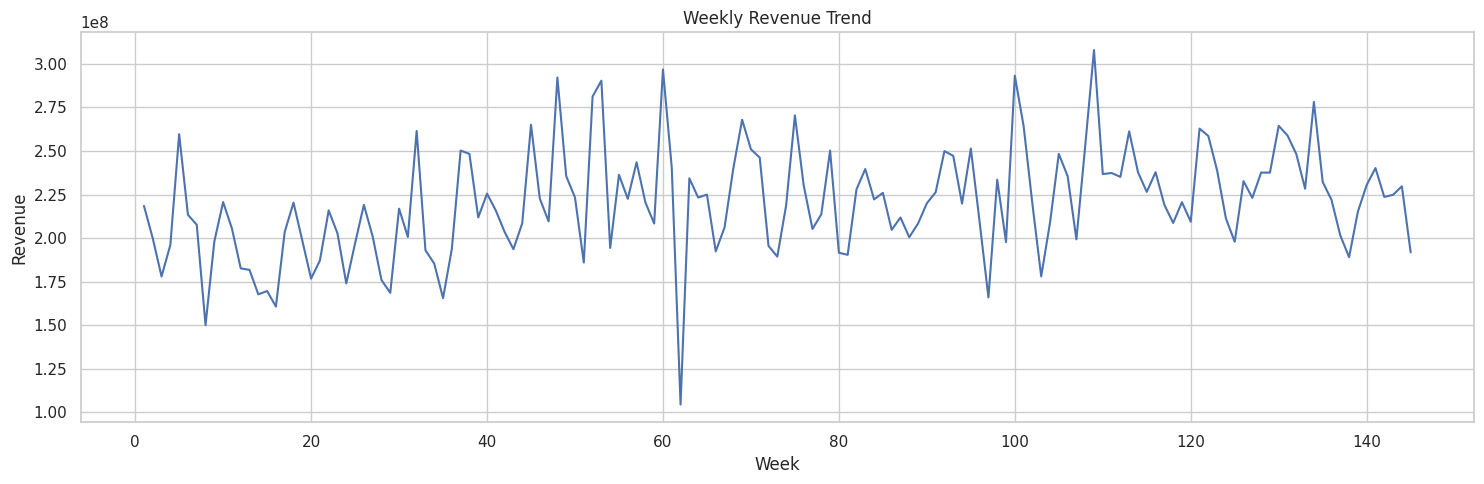

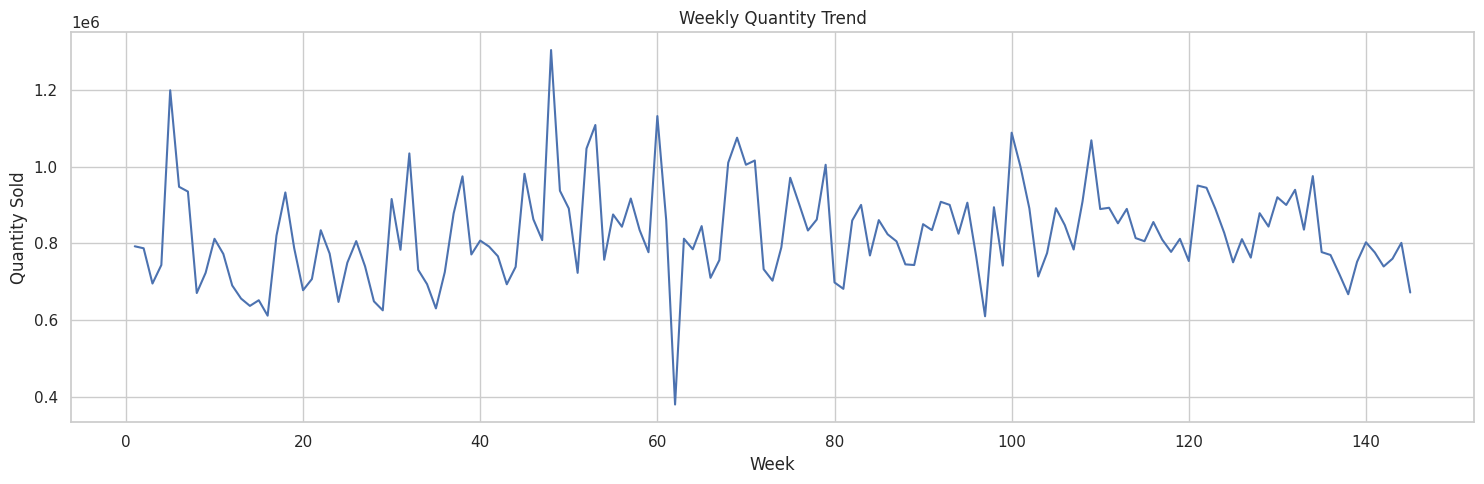

In [6]:
weekly = (
    retail_price.groupby("week")
    .agg(
        Revenue=("Revenue", "sum"),
        Quantity=("Quantity", "sum")
    )
    .reset_index()
    .sort_values("week")
)

plt.figure(figsize=(15, 5))
sns.lineplot(data=weekly, x="week", y="Revenue")
plt.title("Weekly Revenue Trend")
plt.xlabel("Week")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 5))
sns.lineplot(data=weekly, x="week", y="Quantity")
plt.title("Weekly Quantity Trend")
plt.xlabel("Week")
plt.ylabel("Quantity Sold")
plt.tight_layout()
plt.show()


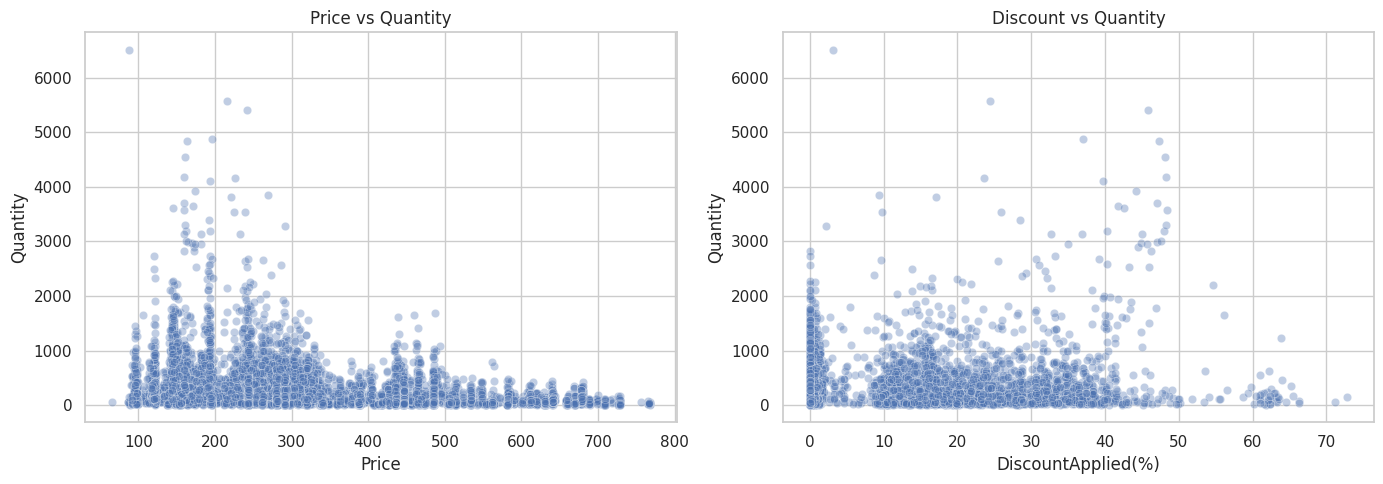

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=retail_price.sample(min(10000, len(retail_price)), random_state=42),
    x="Price", y="Quantity", alpha=0.35, ax=axes[0]
)
axes[0].set_title("Price vs Quantity")

sns.scatterplot(
    data=retail_price.sample(min(10000, len(retail_price)), random_state=42),
    x="DiscountApplied(%)", y="Quantity", alpha=0.35, ax=axes[1]
)
axes[1].set_title("Discount vs Quantity")

plt.tight_layout()
plt.show()


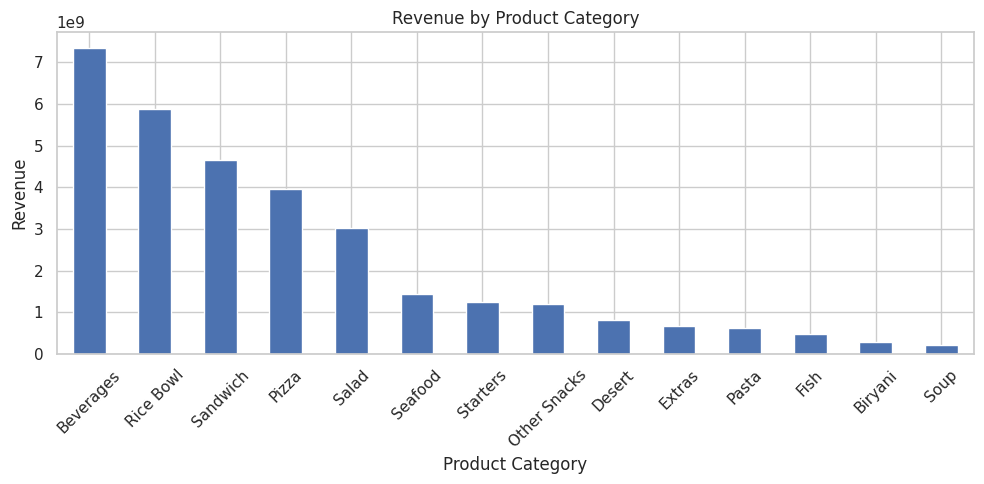

,Revenue
ProductCategory,
Beverages,7.347304e+09
Rice Bowl,5.881531e+09
Sandwich,4.663427e+09
Pizza,3.955956e+09
Salad,3.032256e+09
Seafood,1.447749e+09
Starters,1.259443e+09
Other Snacks,1.209248e+09
Desert,8.208410e+08


In [8]:
category_revenue = (
    retail_price.groupby("ProductCategory")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
category_revenue.plot(kind="bar")
plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(category_revenue.to_frame("Revenue"))


# 6. Create Weekly Meal (Product) Dataset

For pricing analysis, center-level weekly rows can be noisy across fulfilment centers. We aggregate to **Meal (Product) + Week**, summed/averaged across all centers.

This gives us:
- weekly quantity demanded
- average selling price
- average discount
- weekly revenue


In [9]:
# STEP 1/2 — Weekly center × product dataset
# Keep center_id because demand can differ by location.
daily_product = (
    retail_price
    .groupby(["week", "center_id", "ProductID", "ProductCategory"], as_index=False)
    .agg(
        Quantity=("Quantity", "sum"),
        Avg_Price=("Price", "mean"),
        Base_Price=("base_price", "mean"),
        Avg_Discount=("DiscountApplied(%)", "mean"),
        Price_Ratio=("Price_Ratio", "mean"),
        Promotion=("emailer_for_promotion", "max"),
        Homepage_Featured=("homepage_featured", "max"),
        Revenue=("Revenue", "sum")
    )
    .rename(columns={"week": "Date"})
)

daily_product = daily_product.sort_values(
    ["center_id", "ProductID", "Date"]
).reset_index(drop=True)

print("Weekly center-product shape:", daily_product.shape)
display(daily_product.head(10))


Weekly center-product shape: (456548, 12)


,Date,center_id,ProductID,ProductCategory,Quantity,Avg_Price,Base_Price,Avg_Discount,Price_Ratio,Promotion,Homepage_Featured,Revenue
0,1,10,1062,Beverages,865,181.39,181.39,0.000000,1.000000,0,0,156902.35
1,2,10,1062,Beverages,782,183.36,182.36,0.000000,1.005484,0,0,143387.52
2,3,10,1062,Beverages,851,184.36,182.36,0.000000,1.010967,0,0,156890.36
3,4,10,1062,Beverages,1202,182.36,183.36,0.545375,0.994546,0,0,219196.72
4,5,10,1062,Beverages,958,183.39,181.39,0.000000,1.011026,0,0,175687.62
5,6,10,1062,Beverages,1094,162.05,183.39,11.636403,0.883636,0,0,177282.70
6,7,10,1062,Beverages,1513,160.08,183.39,12.710617,0.872894,0,0,242201.04
7,8,10,1062,Beverages,1149,160.05,182.39,12.248479,0.877515,0,0,183897.45
8,9,10,1062,Beverages,1282,162.05,182.39,11.151927,0.888481,0,0,207748.10
9,10,10,1062,Beverages,1473,161.05,181.39,11.213408,0.887866,0,0,237226.65


## 7. Check Price Variation

Elasticity cannot be estimated reliably for a product if its price never changes. We check minimum, maximum, standard deviation, and number of unique prices.

In [10]:
price_variation = (
    daily_product.groupby("ProductID")["Avg_Price"]
    .agg(
        Min_Price="min",
        Max_Price="max",
        Mean_Price="mean",
        Std_Price="std",
        Unique_Prices="nunique"
    )
)

display(price_variation)

,Min_Price,Max_Price,Mean_Price,Std_Price,Unique_Prices
ProductID,,,,,
1062,108.70,195.03,171.315789,11.906733,163
1109,56.26,347.32,268.532165,41.411758,646
1198,64.02,340.53,177.952687,33.741131,341
1207,137.80,515.13,348.482656,53.947875,658
1216,173.63,515.13,395.333775,44.566087,330
1230,2.97,532.53,348.084174,52.507440,666
1247,223.13,505.43,442.668847,29.826065,91
1248,45.62,407.46,142.510589,40.937114,352
1311,64.02,340.53,170.503253,31.930075,366


# 8. Historical Demand Features

All lag/rolling features use `shift(1)` so that today's demand does not leak into today's predictors.

In [11]:
# STEP 2 — Historical demand features (NO target leakage)
g = daily_product.groupby(["center_id", "ProductID"])

daily_product["Lag_1"] = g["Quantity"].shift(1)
daily_product["Lag_2"] = g["Quantity"].shift(2)
daily_product["Lag_4"] = g["Quantity"].shift(4)
daily_product["Rolling_4"] = g["Quantity"].transform(lambda s: s.shift(1).rolling(4).mean())
daily_product["Rolling_12"] = g["Quantity"].transform(lambda s: s.shift(1).rolling(12).mean())

daily_product["Price_Lag_1"] = g["Avg_Price"].shift(1)
daily_product["Price_Change_Pct"] = (
    (daily_product["Avg_Price"] - daily_product["Price_Lag_1"]) /
    daily_product["Price_Lag_1"] * 100
)

daily_product["WeekOfYear"] = daily_product["Date"] % 52
daily_product["WeekSin"] = np.sin(2 * np.pi * daily_product["WeekOfYear"] / 52)
daily_product["WeekCos"] = np.cos(2 * np.pi * daily_product["WeekOfYear"] / 52)

display(daily_product.head(10))


,Date,center_id,ProductID,ProductCategory,Quantity,Avg_Price,Base_Price,Avg_Discount,Price_Ratio,Promotion,...,Lag_1,Lag_2,Lag_4,Rolling_4,Rolling_12,Price_Lag_1,Price_Change_Pct,WeekOfYear,WeekSin,WeekCos
0,1,10,1062,Beverages,865,181.39,181.39,0.000000,1.000000,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0.120537,0.992709
1,2,10,1062,Beverages,782,183.36,182.36,0.000000,1.005484,0,...,865.0,NaN,NaN,NaN,NaN,181.39,1.086058,2,0.239316,0.970942
2,3,10,1062,Beverages,851,184.36,182.36,0.000000,1.010967,0,...,782.0,865.0,NaN,NaN,NaN,183.36,0.545375,3,0.354605,0.935016
3,4,10,1062,Beverages,1202,182.36,183.36,0.545375,0.994546,0,...,851.0,782.0,NaN,NaN,NaN,184.36,-1.084834,4,0.464723,0.885456
4,5,10,1062,Beverages,958,183.39,181.39,0.000000,1.011026,0,...,1202.0,851.0,865.0,925.00,NaN,182.36,0.564817,5,0.568065,0.822984
5,6,10,1062,Beverages,1094,162.05,183.39,11.636403,0.883636,0,...,958.0,1202.0,782.0,948.25,NaN,183.39,-11.636403,6,0.663123,0.748511
6,7,10,1062,Beverages,1513,160.08,183.39,12.710617,0.872894,0,...,1094.0,958.0,851.0,1026.25,NaN,162.05,-1.215674,7,0.748511,0.663123
7,8,10,1062,Beverages,1149,160.05,182.39,12.248479,0.877515,0,...,1513.0,1094.0,1202.0,1191.75,NaN,160.08,-0.018741,8,0.822984,0.568065
8,9,10,1062,Beverages,1282,162.05,182.39,11.151927,0.888481,0,...,1149.0,1513.0,958.0,1178.50,NaN,160.05,1.249609,9,0.885456,0.464723
9,10,10,1062,Beverages,1473,161.05,181.39,11.213408,0.887866,0,...,1282.0,1149.0,1094.0,1259.50,NaN,162.05,-0.617093,10,0.935016,0.354605


# 9. Price Elasticity

### Model

We estimate:

`log(Quantity) = β0 + β1 log(Price) + β2 Discount + error`

Here, **β1 is the estimated price elasticity**, while discount is included as a control variable.

Interpretation:
- Elasticity < -1 → elastic
- -1 < Elasticity < 0 → inelastic
- Elasticity ≈ -1 → unit elastic
- Positive elasticity → unusual for ordinary demand; investigate the data/model before using it for pricing decisions.

In [12]:
# STEP 3 — Improved price elasticity with controls
# Observational estimate: this is association, not proof of a causal price effect.
elasticity_results = []

for product in daily_product["ProductID"].unique():
    temp = daily_product[daily_product["ProductID"] == product].copy()
    temp = temp[(temp["Avg_Price"] > 0) & (temp["Quantity"] > 0)].dropna(
        subset=["Avg_Discount", "Promotion", "Homepage_Featured"]
    )

    if temp["Avg_Price"].nunique() < 2 or len(temp) < 20:
        continue

    temp["log_price"] = np.log(temp["Avg_Price"])
    temp["log_quantity"] = np.log(temp["Quantity"])

    X = sm.add_constant(temp[[
        "log_price", "Avg_Discount", "Promotion", "Homepage_Featured"
    ]])
    y = temp["log_quantity"]
    model = sm.OLS(y, X).fit()

    elasticity_results.append({
        "Product": product,
        "Elasticity": model.params["log_price"],
        "P_Value": model.pvalues["log_price"],
        "R2": model.rsquared,
        "Observations": len(temp)
    })

elasticity_df = pd.DataFrame(elasticity_results)

def classify_elasticity(e):
    if e < -1:
        return "Elastic"
    elif e < 0:
        return "Inelastic"
    elif np.isclose(e, 0, atol=0.05):
        return "Very Weak / Near Zero"
    else:
        return "Positive - Investigate"

elasticity_df["Classification"] = elasticity_df["Elasticity"].apply(classify_elasticity)
display(elasticity_df.sort_values("Elasticity"))


,Product,Elasticity,P_Value,R2,Observations,Classification
50,2956,-4.426839,4.455205e-27,0.112485,3319,Elastic
14,1571,-4.063759,3.953812e-32,0.128071,4511,Elastic
34,2444,-3.914684,2.601908e-235,0.478675,9097,Elastic
10,1445,-3.463334,1.394430e-192,0.436879,9727,Elastic
12,1543,-3.236716,5.218005e-105,0.139402,10236,Elastic
49,2867,-3.129373,2.498660e-134,0.380151,8092,Elastic
31,2304,-2.826835,4.196271e-92,0.156862,9676,Elastic
20,1847,-2.766257,4.992698e-113,0.144014,4084,Elastic
21,1878,-2.707840,2.567547e-79,0.104287,10527,Elastic
27,2104,-2.694942,1.622789e-10,0.174230,2357,Elastic


## 10. Elasticity Visualization

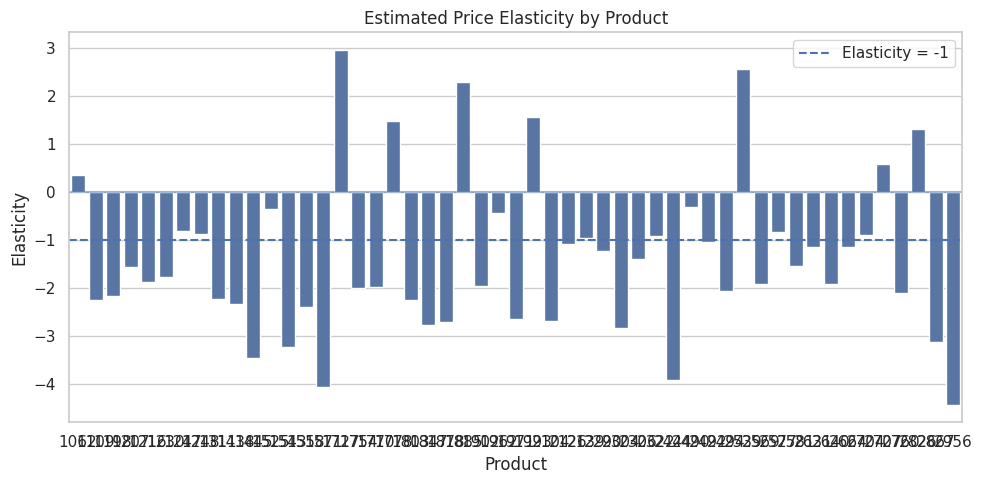

In [13]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=elasticity_df.sort_values("Elasticity"),
    x="Product",
    y="Elasticity"
)
plt.axhline(-1, linestyle="--", label="Elasticity = -1")
plt.axhline(0, linestyle="-", alpha=0.5)
plt.title("Estimated Price Elasticity by Product")
plt.legend()
plt.tight_layout()
plt.show()

# 11. Demand Prediction Dataset

We predict daily product quantity using price, discount, historical demand, and calendar variables.

We use a **time-based split** instead of a random train/test split because pricing decisions are made for the future.

In [14]:
# STEP 4 — Demand prediction dataset + strict chronological split
model_df = daily_product.dropna(subset=[
    "Quantity", "Avg_Price", "Base_Price", "Avg_Discount",
    "Lag_1", "Lag_2", "Lag_4", "Rolling_4", "Rolling_12"
]).copy()

model_df = model_df.sort_values(["Date", "center_id", "ProductID"]).reset_index(drop=True)

features = [
    "Avg_Price", "Base_Price", "Avg_Discount", "Price_Ratio",
    "Promotion", "Homepage_Featured",
    "Lag_1", "Lag_2", "Lag_4", "Rolling_4", "Rolling_12",
    "WeekOfYear", "WeekSin", "WeekCos"
]
cat_features = ["center_id", "ProductID", "ProductCategory"]

X = model_df[features + cat_features].copy()
X = pd.get_dummies(X, columns=cat_features, drop_first=True, dtype=float)
y = model_df["Quantity"]

split_index = int(len(model_df) * 0.80)
X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()
y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

print("Train period:", model_df.loc[:split_index-1, "Date"].min(), "to", model_df.loc[:split_index-1, "Date"].max())
print("Test period :", model_df.loc[split_index:, "Date"].min(), "to", model_df.loc[split_index:, "Date"].max())
print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)


Train period: 13 to 120
Test period : 120 to 145
Train: (330854, 153) (330854,)
Test : (82714, 153) (82714,)


# 12. Train and Compare Models

## STEP 5A — Baseline model evaluation

We first evaluate the existing model comparison using MAE, RMSE and R².

**Important:** Adjusted R² is included as a supplementary statistic. It is mainly designed for linear regression; for tree/boosting models, RMSE, MAE and out-of-sample R² are more useful for model selection.

In [15]:
# STEP 5A — Baseline model evaluation with R² and Adjusted R²

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=14,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        n_estimators=600,
        max_depth=7,
        learning_rate=0.05,
        min_child_weight=3,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )
}

results = []
predictions = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)

    pred = np.maximum(0, model.predict(X_test))
    predictions[name] = pred

    n = len(y_test)
    p = X_test.shape[1]
    r2 = r2_score(y_test, pred)

    # Adjusted R² is reported as a supplementary metric.
    if n > p + 1:
        adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
    else:
        adjusted_r2 = np.nan

    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2": r2,
        "Adjusted_R2": adjusted_r2
    })

model_results = (
    pd.DataFrame(results)
    .sort_values(["RMSE", "MAE"])
    .reset_index(drop=True)
)

best_model_name = model_results.iloc[0]["Model"]
best_model = models[best_model_name]

print("Best baseline model:", best_model_name)
display(model_results.round(4))

print("Observations (n):", len(y_test))
print("Encoded features (p):", X_test.shape[1])

Training Linear Regression...
Training Random Forest...
Training XGBoost...
Best baseline model: XGBoost


,Model,MAE,RMSE,R2,Adjusted_R2
0,XGBoost,70.1498,156.2831,0.8175,0.8172
1,Random Forest,71.0942,158.1054,0.8133,0.8129
2,Linear Regression,94.4243,204.8423,0.6865,0.6860


Observations (n): 82714
Encoded features (p): 153


## STEP 5B — Feature importance

For the baseline XGBoost model, inspect which variables contribute most to demand prediction. This helps explain the model and identify useful features.

,Feature,Importance
0,Rolling_12,0.114281
1,Promotion,0.110819
2,Lag_1,0.091484
3,center_id_43,0.047586
4,ProductCategory_Sandwich,0.032983
5,Homepage_Featured,0.029085
6,ProductCategory_Rice Bowl,0.022162
7,ProductID_1727,0.021540
8,Avg_Discount,0.021503
9,ProductCategory_Salad,0.019431


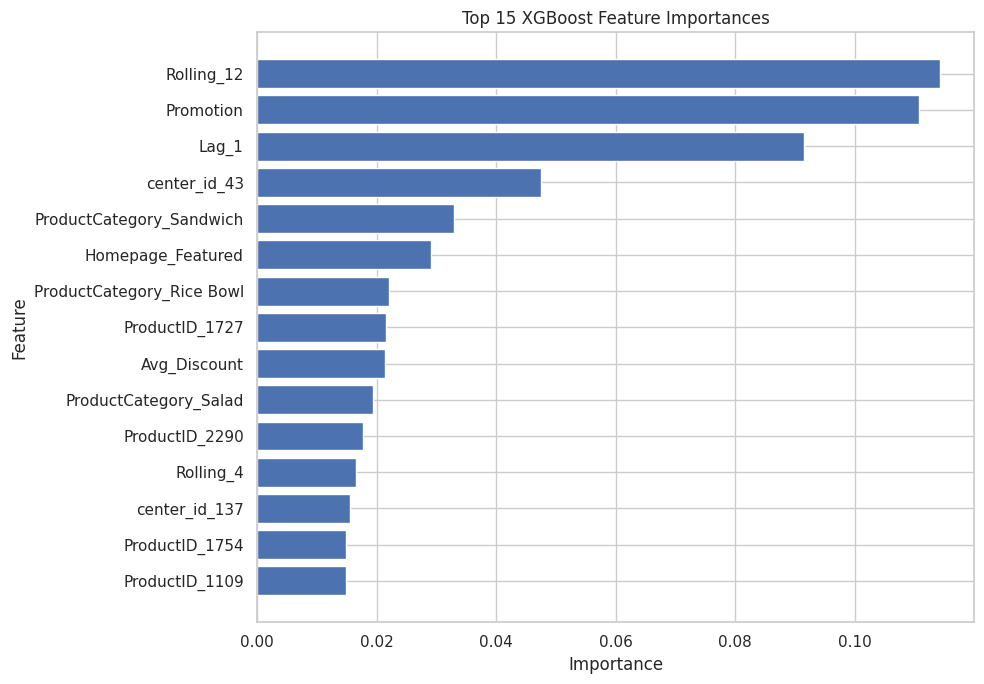

In [16]:
# STEP 5B — XGBoost feature importance

xgb_baseline = models["XGBoost"]

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_baseline.feature_importances_
}).sort_values(
    by="Importance", ascending=False
).reset_index(drop=True)

display(importance.head(20))

plt.figure(figsize=(10, 7))
top_imp = importance.head(15).sort_values("Importance")
plt.barh(top_imp["Feature"], top_imp["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Feature Importances")
plt.tight_layout()
plt.show()

## STEP 5C — Baseline residual analysis

Residuals are:

`Residual = Actual Demand − Predicted Demand`

We check whether errors are centered around zero and whether error size changes with predicted demand.

Baseline model: XGBoost
Mean Residual: 3.4651
Residual Std : 156.2447
MAE          : 70.1498
RMSE         : 156.2831


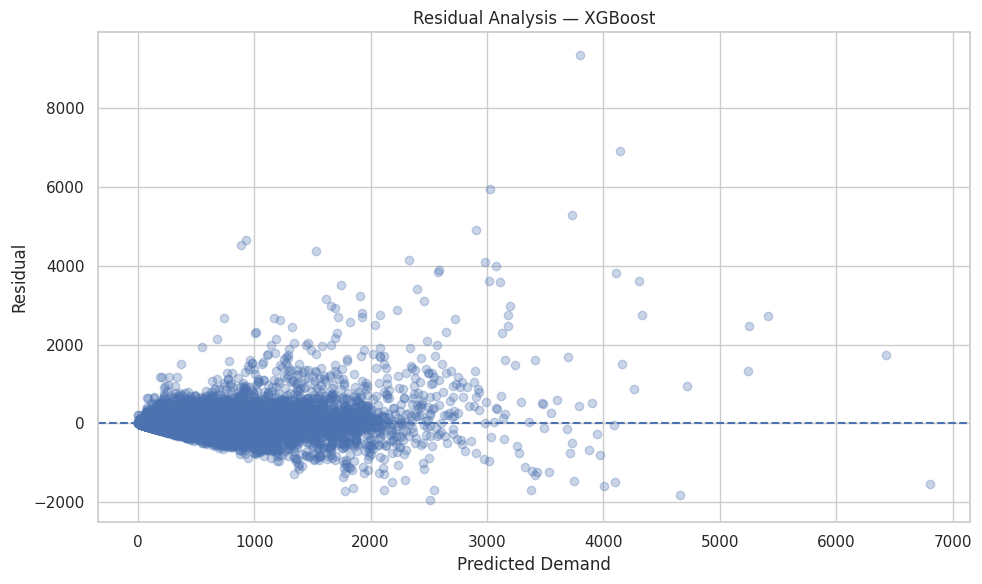

In [17]:
# STEP 5C — Baseline residual analysis

baseline_pred = predictions[best_model_name]
baseline_residuals = y_test.to_numpy() - baseline_pred

print("Baseline model:", best_model_name)
print("Mean Residual:", round(float(baseline_residuals.mean()), 4))
print("Residual Std :", round(float(baseline_residuals.std()), 4))
print("MAE          :", round(float(mean_absolute_error(y_test, baseline_pred)), 4))
print("RMSE         :", round(float(np.sqrt(mean_squared_error(y_test, baseline_pred))), 4))

plt.figure(figsize=(10, 6))
plt.scatter(baseline_pred, baseline_residuals, alpha=0.30)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Demand")
plt.ylabel("Residual")
plt.title(f"Residual Analysis — {best_model_name}")
plt.tight_layout()
plt.show()

## STEP 5D — Tuned XGBoost

We now tune XGBoost using a stronger configuration. The goal is to improve out-of-sample RMSE/MAE and potentially R².

**Note:** Higher R² is not guaranteed. The tuned model is accepted only if it actually improves the test metrics.

In [18]:
# STEP 5D — Tuned XGBoost configuration

xgb_tuned = XGBRegressor(
    n_estimators=1500,
    max_depth=6,
    learning_rate=0.03,
    min_child_weight=3,
    subsample=0.90,
    colsample_bytree=0.90,
    gamma=0,
    reg_alpha=0.10,
    reg_lambda=1.50,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

print(xgb_tuned)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1500,
             n_jobs=-1, num_parallel_tree=None, ...)


In [19]:
# STEP 5E — Train tuned XGBoost

print("Training tuned XGBoost...")
xgb_tuned.fit(X_train, y_train)
print("Training completed!")

Training tuned XGBoost...
Training completed!


In [20]:
# STEP 5F — Tuned XGBoost predictions

y_pred_tuned = np.maximum(0, xgb_tuned.predict(X_test))
print("Prediction completed!")
print("Predictions:", len(y_pred_tuned))

Prediction completed!
Predictions: 82714


In [21]:
# STEP 5G — Tuned XGBoost metrics

mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)

n = len(y_test)
p = X_test.shape[1]

if n > p + 1:
    adjusted_r2_tuned = 1 - ((1 - r2_tuned) * (n - 1) / (n - p - 1))
else:
    adjusted_r2_tuned = np.nan

print("Tuned XGBoost Results")
print("---------------------")
print("MAE          :", round(mae_tuned, 4))
print("RMSE         :", round(rmse_tuned, 4))
print("R²           :", round(r2_tuned, 4))
print("Adjusted R²  :", round(adjusted_r2_tuned, 4))

Tuned XGBoost Results
---------------------
MAE          : 70.2887
RMSE         : 155.7591
R²           : 0.8188
Adjusted R²  : 0.8184


## STEP 5H — Original vs tuned XGBoost

Use this comparison to decide whether tuning actually helped. The primary decision rule is lower RMSE, followed by MAE; R² and Adjusted R² are reported for interpretation.

In [22]:
# STEP 5H — Original vs tuned XGBoost comparison

old_pred = predictions["XGBoost"]

old_mae = mean_absolute_error(y_test, old_pred)
old_rmse = np.sqrt(mean_squared_error(y_test, old_pred))
old_r2 = r2_score(y_test, old_pred)

if n > p + 1:
    old_adjusted_r2 = 1 - ((1 - old_r2) * (n - 1) / (n - p - 1))
else:
    old_adjusted_r2 = np.nan

comparison = pd.DataFrame({
    "Model": ["Original XGBoost", "Tuned XGBoost"],
    "MAE": [old_mae, mae_tuned],
    "RMSE": [old_rmse, rmse_tuned],
    "R2": [old_r2, r2_tuned],
    "Adjusted_R2": [old_adjusted_r2, adjusted_r2_tuned]
})

display(comparison.round(4))

if rmse_tuned < old_rmse:
    print("Tuned XGBoost improved RMSE → selecting Tuned XGBoost.")
    best_model = xgb_tuned
    best_model_name = "Tuned XGBoost"
    predictions["Tuned XGBoost"] = y_pred_tuned
else:
    print("Original XGBoost has equal or better RMSE → keeping Original XGBoost.")
    best_model = models["XGBoost"]
    best_model_name = "XGBoost"

print("Selected model:", best_model_name)

,Model,MAE,RMSE,R2,Adjusted_R2
0,Original XGBoost,70.1498,156.2831,0.8175,0.8172
1,Tuned XGBoost,70.2887,155.7591,0.8188,0.8184


Tuned XGBoost improved RMSE → selecting Tuned XGBoost.
Selected model: Tuned XGBoost


## STEP 5I — Tuned model feature importance

,Feature,Importance
0,Lag_1,0.122172
1,Rolling_12,0.117671
2,Promotion,0.105813
3,center_id_43,0.056110
4,Homepage_Featured,0.030018
5,ProductCategory_Sandwich,0.027597
6,ProductCategory_Salad,0.022591
7,Avg_Discount,0.021425
8,Rolling_4,0.019561
9,ProductCategory_Rice Bowl,0.018546


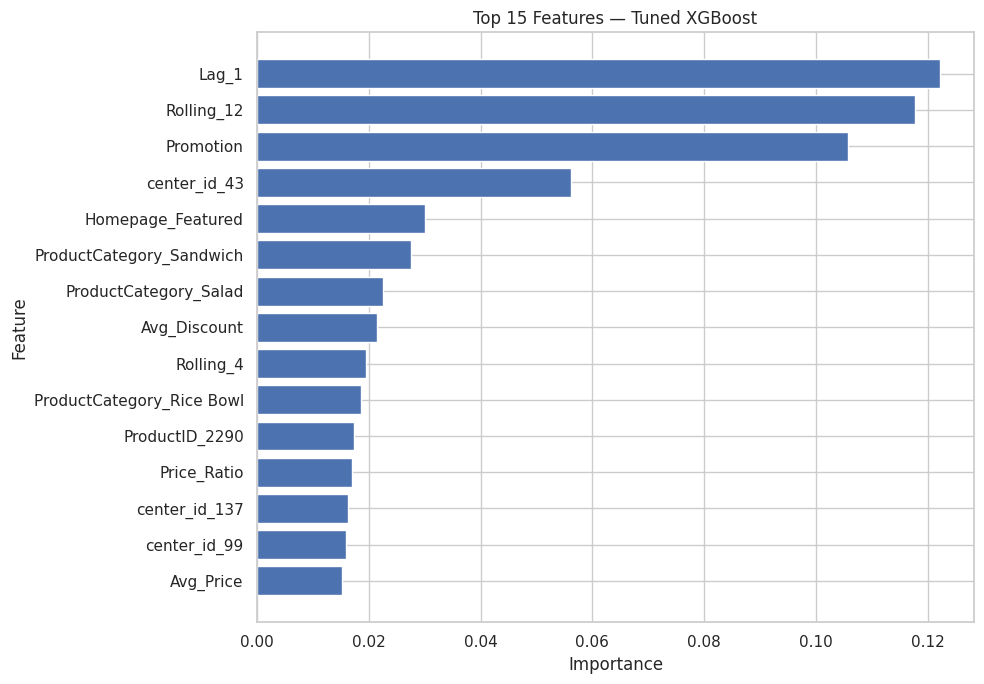

In [23]:
# STEP 5I — Feature importance of the selected XGBoost model

if best_model_name == "Tuned XGBoost":
    selected_xgb = xgb_tuned
else:
    selected_xgb = models["XGBoost"]

selected_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": selected_xgb.feature_importances_
}).sort_values(
    by="Importance", ascending=False
).reset_index(drop=True)

display(selected_importance.head(20))

plt.figure(figsize=(10, 7))
top_selected = selected_importance.head(15).sort_values("Importance")
plt.barh(top_selected["Feature"], top_selected["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title(f"Top 15 Features — {best_model_name}")
plt.tight_layout()
plt.show()

In [24]:
# STEP 5J — Final selected-model metrics

best_pred = predictions[best_model_name]

final_n = len(y_test)
final_p = X_test.shape[1]
final_r2 = r2_score(y_test, best_pred)

if final_n > final_p + 1:
    final_adjusted_r2 = 1 - ((1 - final_r2) * (final_n - 1) / (final_n - final_p - 1))
else:
    final_adjusted_r2 = np.nan

final_metrics = pd.DataFrame([{
    "Selected Model": best_model_name,
    "MAE": mean_absolute_error(y_test, best_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, best_pred)),
    "R2": final_r2,
    "Adjusted_R2": final_adjusted_r2,
    "Observations": final_n,
    "Encoded_Features": final_p
}])

display(final_metrics.round(4))

,Selected Model,MAE,RMSE,R2,Adjusted_R2,Observations,Encoded_Features
0,Tuned XGBoost,70.2887,155.7591,0.8188,0.8184,82714,153


# 13. Actual vs Predicted Demand

We inspect the best model from the comparison.

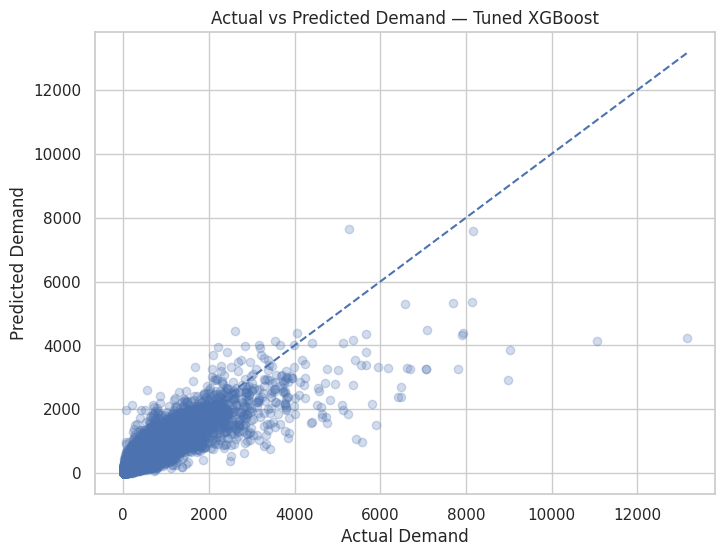

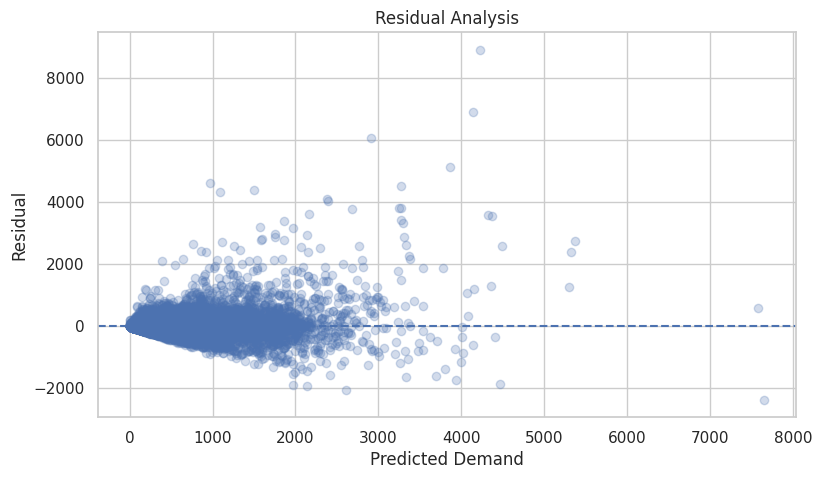

In [25]:
# STEP 5K — Final selected model: actual vs predicted demand + residual check
best_pred = predictions[best_model_name]

plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_pred, alpha=0.25)
lims = [min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())]
plt.plot(lims, lims, linestyle="--")
plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title(f"Actual vs Predicted Demand — {best_model_name}")
plt.show()

residuals = y_test.to_numpy() - best_pred
plt.figure(figsize=(9, 5))
plt.scatter(best_pred, residuals, alpha=0.25)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Demand")
plt.ylabel("Residual")
plt.title("Residual Analysis")
plt.show()


# 14. Price Simulation & Revenue Optimization

Now we move from prediction to the actual **dynamic pricing** task.

For each product, we test a range of possible prices and use the demand model to estimate expected quantity and revenue.

### Revenue

`Revenue = Price × Predicted Demand`

> The simulation is a model-based scenario analysis, not a guarantee that changing price will cause the predicted demand.

In [30]:
print(pricing_df.columns.tolist())
print(pricing_df.shape)
display(pricing_df.head())

['center_id_original', 'ProductID_original', 'CurrentPrice', 'Avg_Price', 'CandidatePrice', 'PredictedDemand', 'ExpectedRevenue']
(74928, 7)


,center_id_original,ProductID_original,CurrentPrice,Avg_Price,CandidatePrice,PredictedDemand,ExpectedRevenue
0,41,2631,252.23,201.7840,201.7840,56.195724,11339.398070
1,41,2631,252.23,206.8286,206.8286,56.450264,11675.529068
2,41,2631,252.23,211.8732,211.8732,56.468884,11964.243051
3,41,2631,252.23,216.9178,216.9178,56.484097,12252.405954
4,41,2631,252.23,221.9624,221.9624,57.032360,12659.039520


In [31]:
latest_rows = (
    model_df.sort_values("Date")
    .groupby(["center_id", "ProductID"], as_index=False)
    .tail(1)
)

print("Latest rows:", len(latest_rows))
display(latest_rows.head())

Latest rows: 3568


,Date,center_id,ProductID,ProductCategory,Quantity,Avg_Price,Base_Price,Avg_Discount,Price_Ratio,Promotion,...,Lag_1,Lag_2,Lag_4,Rolling_4,Rolling_12,Price_Lag_1,Price_Change_Pct,WeekOfYear,WeekSin,WeekCos
18314,20,41,2631,Beverages,14,252.23,252.23,0.000000,1.000000,0,...,54.0,41.0,15.0,68.25,70.083333,251.23,0.398042,20,0.663123,-0.748511
66253,37,41,1445,Seafood,15,668.33,668.33,0.000000,1.000000,0,...,13.0,15.0,14.0,13.75,31.750000,669.33,-0.149403,37,-0.970942,-0.239316
84252,43,41,1311,Extras,27,162.05,214.43,24.427552,0.755724,0,...,121.0,54.0,67.0,74.00,74.416667,214.43,-24.427552,43,-0.885456,0.464723
87329,44,41,1803,Extras,28,162.05,214.43,24.427552,0.755724,0,...,54.0,94.0,68.0,74.50,52.083333,160.05,1.249609,44,-0.822984,0.568065
87320,44,41,1198,Extras,28,161.05,321.13,49.848971,0.501510,0,...,94.0,15.0,27.0,51.25,45.500000,138.77,16.055343,44,-0.822984,0.568065


In [32]:
# STEP 6 — Fast Price Simulation

pricing_rows = []

for _, row in latest_rows.iterrows():

    current_price = row["Avg_Price"]

    candidate_prices = np.linspace(
        current_price * 0.80,
        current_price * 1.20,
        21
    )

    for price in candidate_prices:

        base_price = row["Base_Price"]

        discount_pct = max(
            0,
            (base_price - price) / base_price * 100
        )

        price_ratio = price / base_price

        pricing_rows.append({
            "center_id": row["center_id"],
            "ProductID": row["ProductID"],
            "ProductCategory": row["ProductCategory"],
            "CurrentPrice": current_price,
            "CandidatePrice": price,

            "Avg_Price": price,
            "Base_Price": base_price,
            "Avg_Discount": discount_pct,
            "Price_Ratio": price_ratio,

            "Promotion": row["Promotion"],
            "Homepage_Featured": row["Homepage_Featured"],

            "Lag_1": row["Lag_1"],
            "Lag_2": row["Lag_2"],
            "Lag_4": row["Lag_4"],
            "Rolling_4": row["Rolling_4"],
            "Rolling_12": row["Rolling_12"],

            "WeekOfYear": row["WeekOfYear"],
            "WeekSin": row["WeekSin"],
            "WeekCos": row["WeekCos"]
        })

simulation_input = pd.DataFrame(pricing_rows)

print("Simulation rows:", len(simulation_input))
display(simulation_input.head())

Simulation rows: 74928


,center_id,ProductID,ProductCategory,CurrentPrice,CandidatePrice,Avg_Price,Base_Price,Avg_Discount,Price_Ratio,Promotion,Homepage_Featured,Lag_1,Lag_2,Lag_4,Rolling_4,Rolling_12,WeekOfYear,WeekSin,WeekCos
0,41,2631,Beverages,252.23,201.7840,201.7840,252.23,20.0,0.80,0,0,54.0,41.0,15.0,68.25,70.083333,20,0.663123,-0.748511
1,41,2631,Beverages,252.23,206.8286,206.8286,252.23,18.0,0.82,0,0,54.0,41.0,15.0,68.25,70.083333,20,0.663123,-0.748511
2,41,2631,Beverages,252.23,211.8732,211.8732,252.23,16.0,0.84,0,0,54.0,41.0,15.0,68.25,70.083333,20,0.663123,-0.748511
3,41,2631,Beverages,252.23,216.9178,216.9178,252.23,14.0,0.86,0,0,54.0,41.0,15.0,68.25,70.083333,20,0.663123,-0.748511
4,41,2631,Beverages,252.23,221.9624,221.9624,252.23,12.0,0.88,0,0,54.0,41.0,15.0,68.25,70.083333,20,0.663123,-0.748511


In [33]:
X_candidate = pd.get_dummies(
    simulation_input[
        [
            "Avg_Price",
            "Base_Price",
            "Avg_Discount",
            "Price_Ratio",
            "Promotion",
            "Homepage_Featured",
            "Lag_1",
            "Lag_2",
            "Lag_4",
            "Rolling_4",
            "Rolling_12",
            "WeekOfYear",
            "WeekSin",
            "WeekCos",
            "center_id",
            "ProductID",
            "ProductCategory"
        ]
    ],
    columns=["center_id", "ProductID", "ProductCategory"],
    drop_first=True,
    dtype=float
)

X_candidate = X_candidate.reindex(
    columns=X_train.columns,
    fill_value=0
)

print("Prediction matrix:", X_candidate.shape)

Prediction matrix: (74928, 153)


In [34]:
predicted_demand = best_model.predict(X_candidate)
predicted_demand = np.maximum(predicted_demand, 0)

simulation_input["PredictedDemand"] = predicted_demand

simulation_input["ExpectedRevenue"] = (
    simulation_input["CandidatePrice"]
    * simulation_input["PredictedDemand"]
)

In [35]:
pricing_df = simulation_input[
    [
        "center_id",
        "ProductID",
        "CurrentPrice",
        "CandidatePrice",
        "PredictedDemand",
        "ExpectedRevenue"
    ]
].copy()

print("Pricing dataframe:", pricing_df.shape)
display(pricing_df.head(20))

Pricing dataframe: (74928, 6)


,center_id,ProductID,CurrentPrice,CandidatePrice,PredictedDemand,ExpectedRevenue
0,41,2631,252.23,201.7840,56.195724,11339.398070
1,41,2631,252.23,206.8286,56.450264,11675.529068
2,41,2631,252.23,211.8732,56.468884,11964.243051
3,41,2631,252.23,216.9178,56.484097,12252.405954
4,41,2631,252.23,221.9624,57.032360,12659.039520
5,41,2631,252.23,227.0070,43.102539,9784.578085
6,41,2631,252.23,232.0516,44.352592,10292.090046
7,41,2631,252.23,237.0962,41.745338,9897.661112
8,41,2631,252.23,242.1408,42.371666,10259.909092
9,41,2631,252.23,247.1854,41.764854,10323.662249


# 15. Find Revenue-Maximizing Price

In [36]:
# STEP 7 — Revenue-maximizing price
# Aggregate expected revenue across centers, then choose one recommended price per product.
product_revenue_curve = (
    pricing_df
    .groupby(["ProductID", "CandidatePrice"], as_index=False)
    .agg(
        PredictedDemand=("PredictedDemand", "sum"),
        ExpectedRevenue=("ExpectedRevenue", "sum"),
        CurrentPrice=("CurrentPrice", "mean")
    )
)

optimal_prices = (
    product_revenue_curve.loc[
        product_revenue_curve.groupby("ProductID")["ExpectedRevenue"].idxmax()
    ]
    .sort_values("ProductID")
    .reset_index(drop=True)
)

optimal_prices["PriceChangePct"] = (
    (optimal_prices["CandidatePrice"] - optimal_prices["CurrentPrice"])
    / optimal_prices["CurrentPrice"] * 100
)

display(optimal_prices)


,ProductID,CandidatePrice,PredictedDemand,ExpectedRevenue,CurrentPrice,PriceChangePct
0,1062,229.3080,2029.107422,4.652906e+05,191.090000,20.000000
1,1109,334.1844,2276.667480,7.608267e+05,305.873333,9.255814
2,1198,182.0550,1576.705566,2.870471e+05,171.750000,6.000000
3,1207,465.6000,666.343933,3.102497e+05,388.000000,20.000000
4,1216,500.5560,954.844666,4.779532e+05,417.130000,20.000000
5,1230,378.3000,491.886414,1.860806e+05,371.025000,1.960784
6,1247,536.6760,729.696472,3.916106e+05,447.230000,20.000000
7,1248,197.9160,757.222473,1.498664e+05,164.930000,20.000000
8,1311,193.2600,1029.451172,1.989517e+05,161.050000,20.000000
9,1438,234.0000,1676.198975,3.922306e+05,195.000000,20.000000


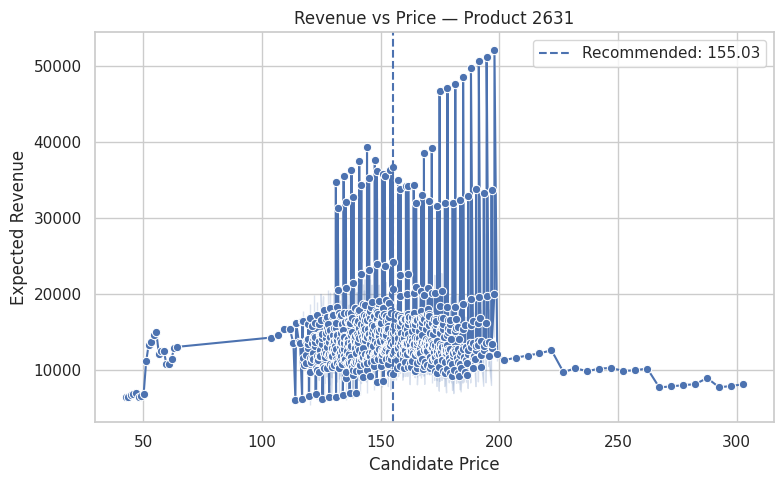

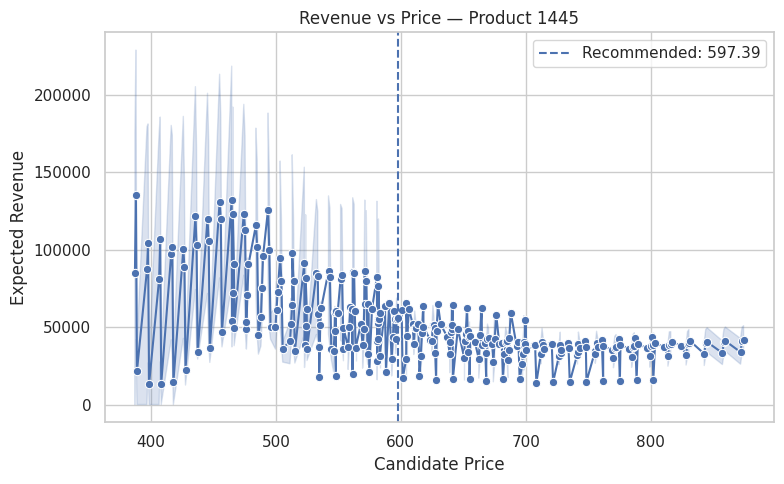

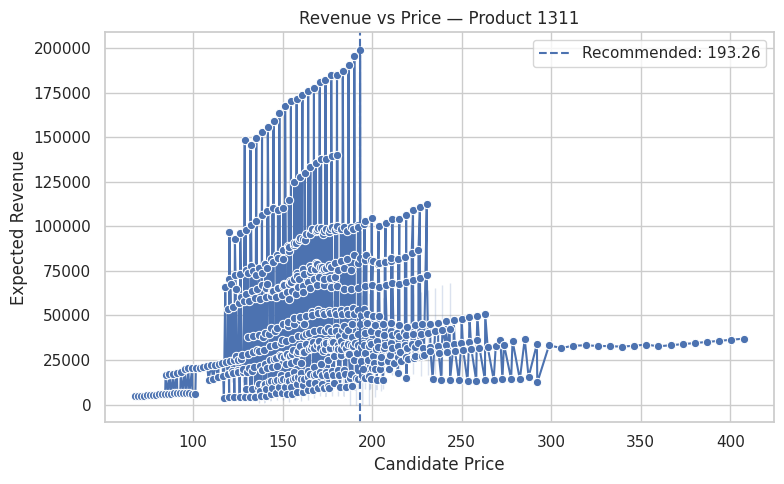

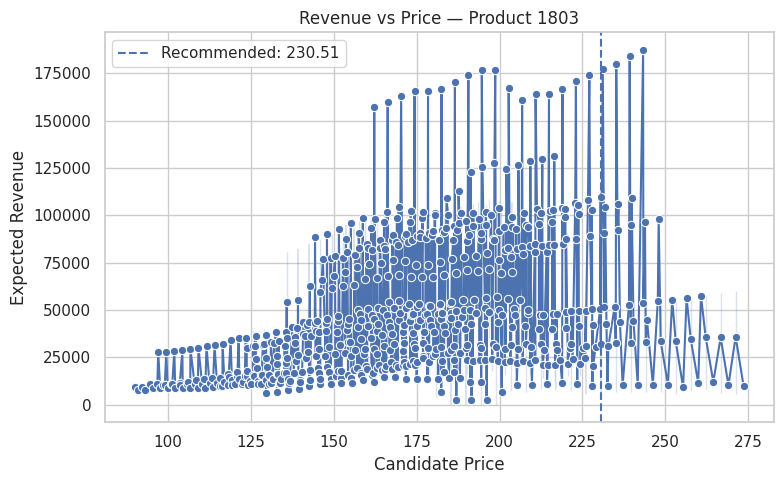

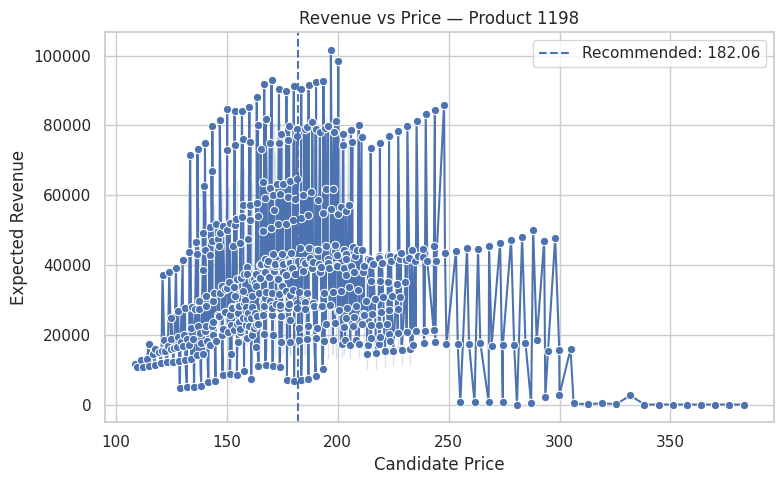

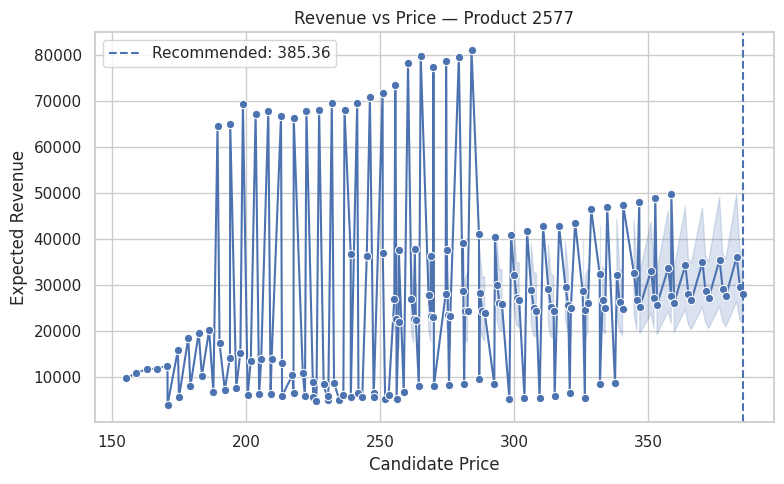

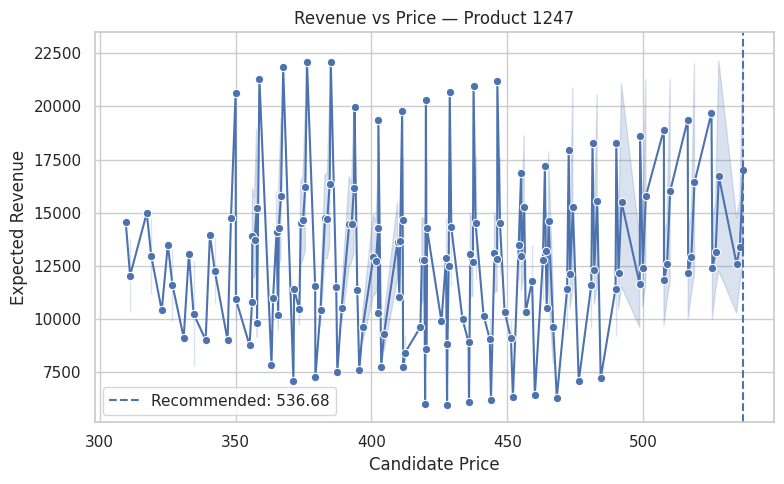

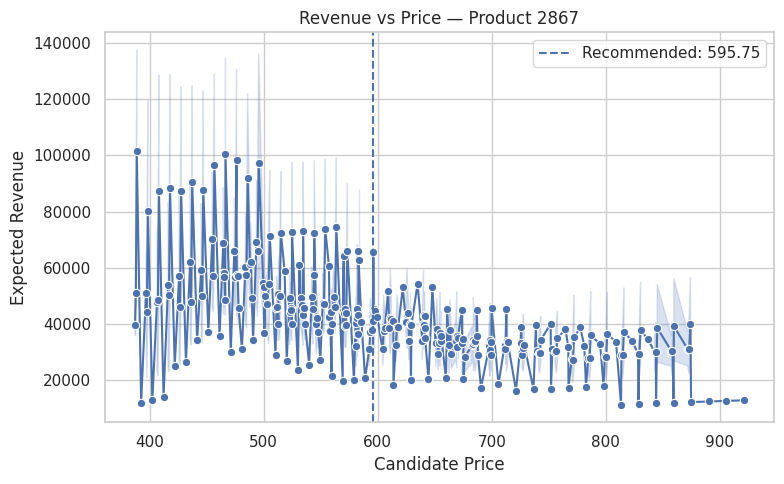

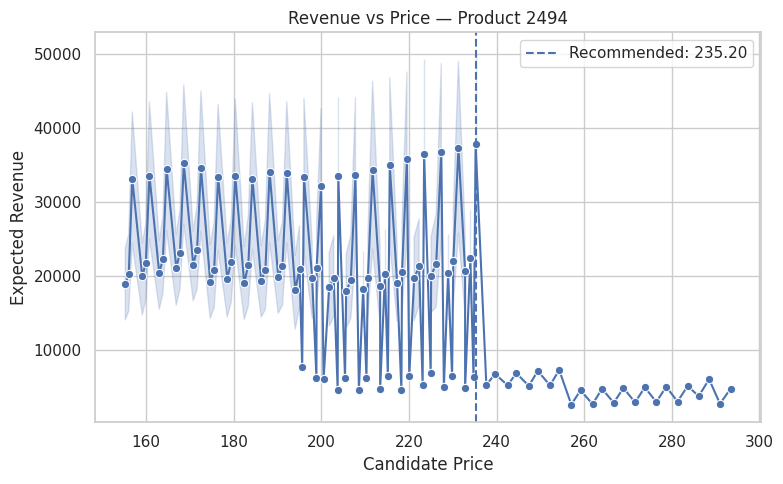

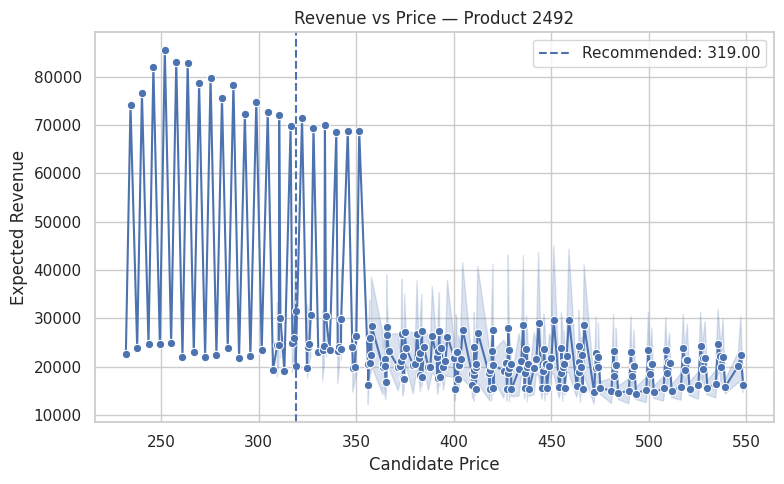

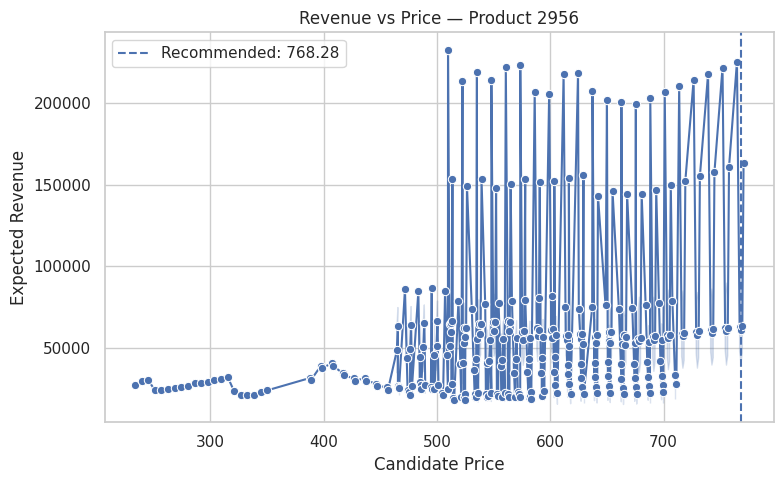

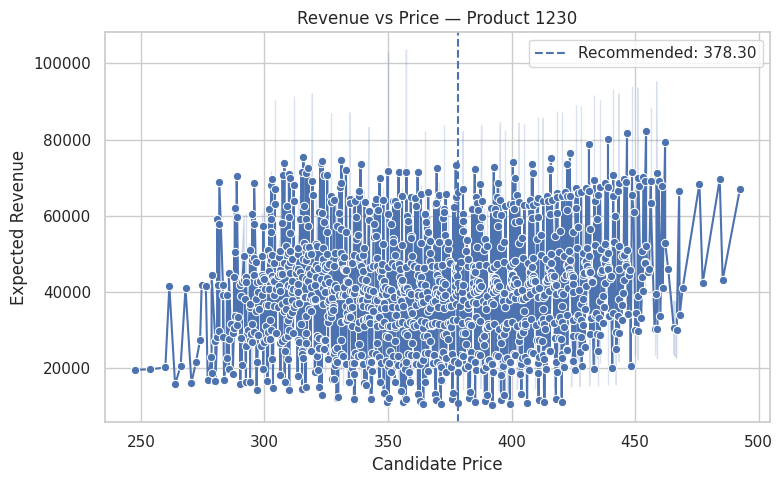

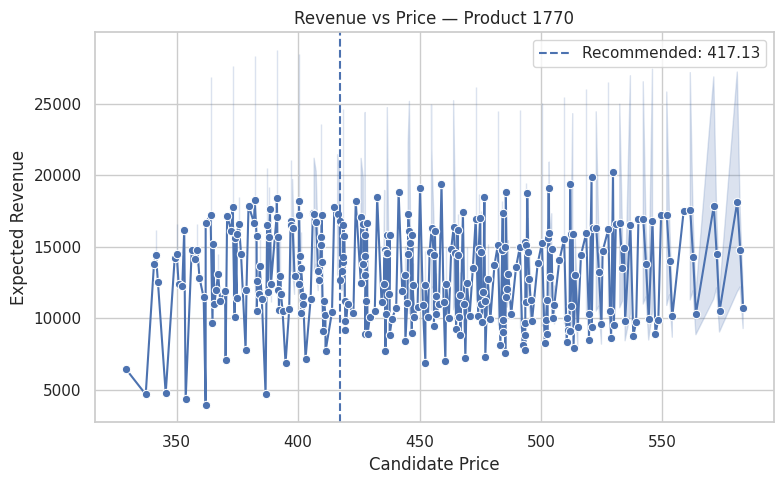

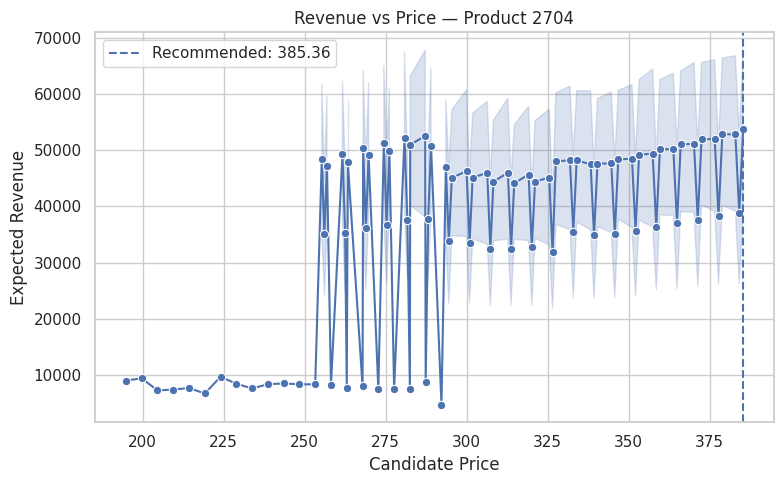

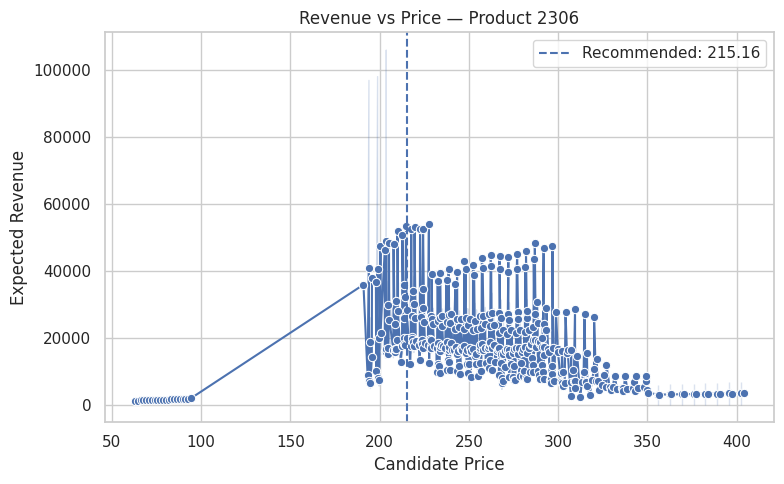

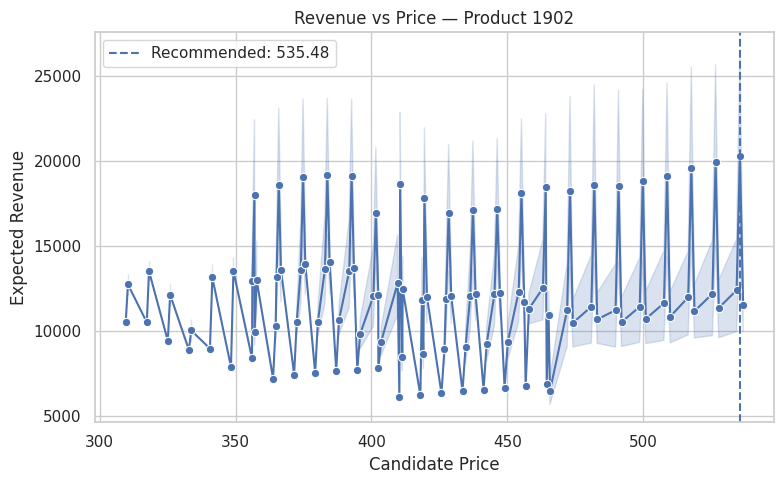

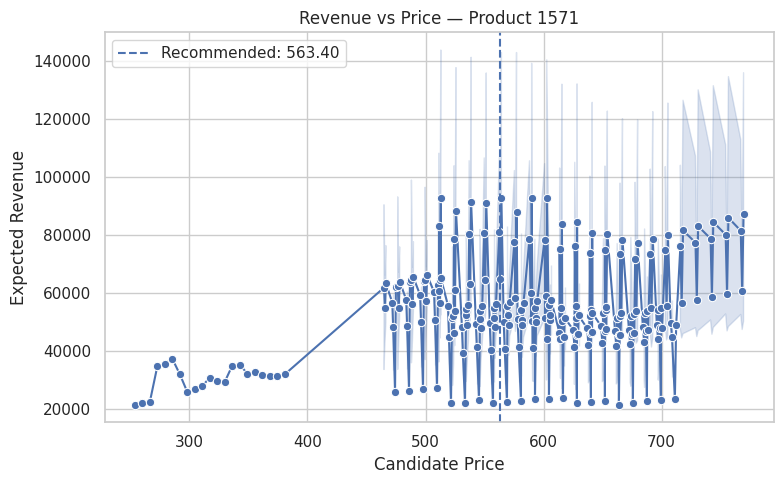

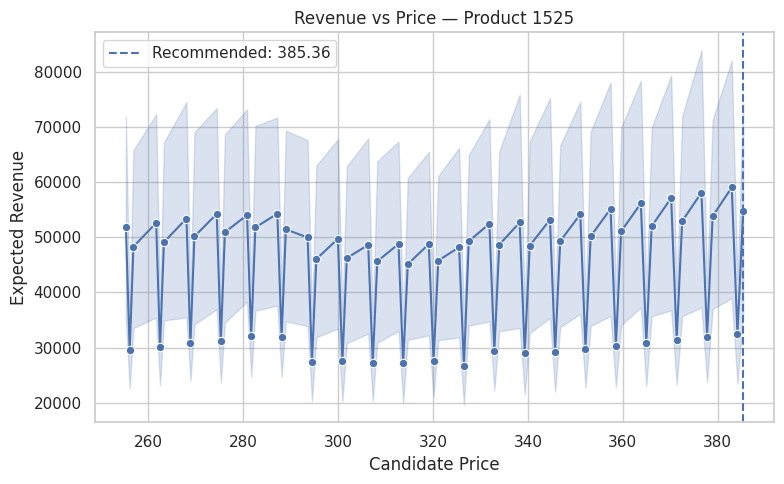

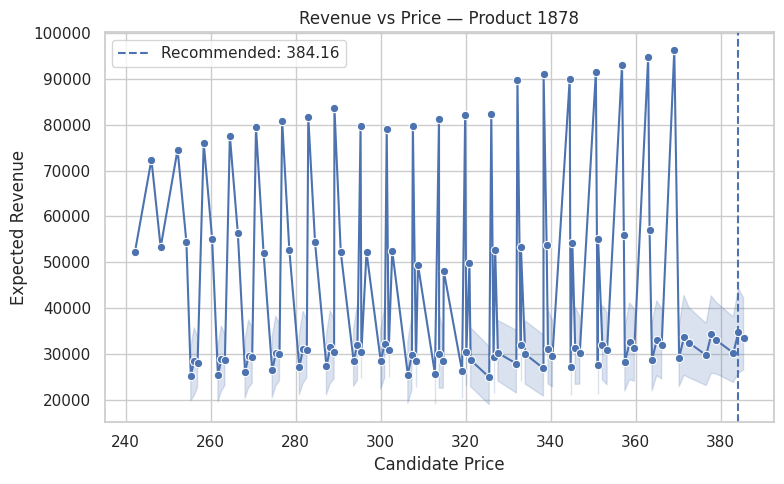

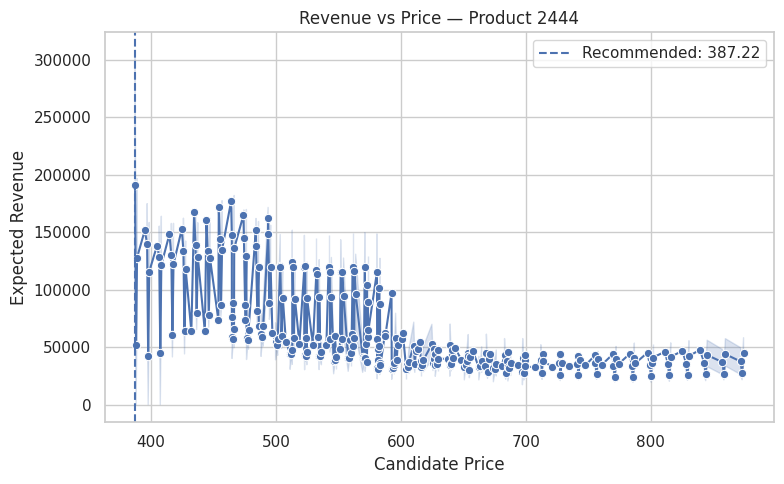

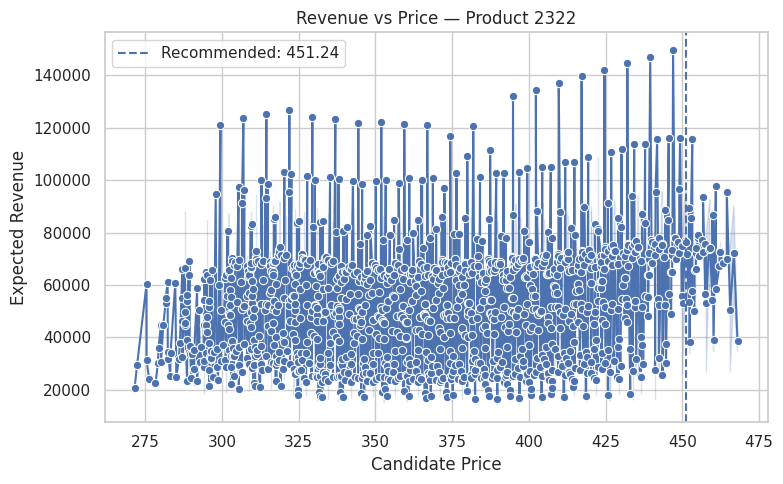

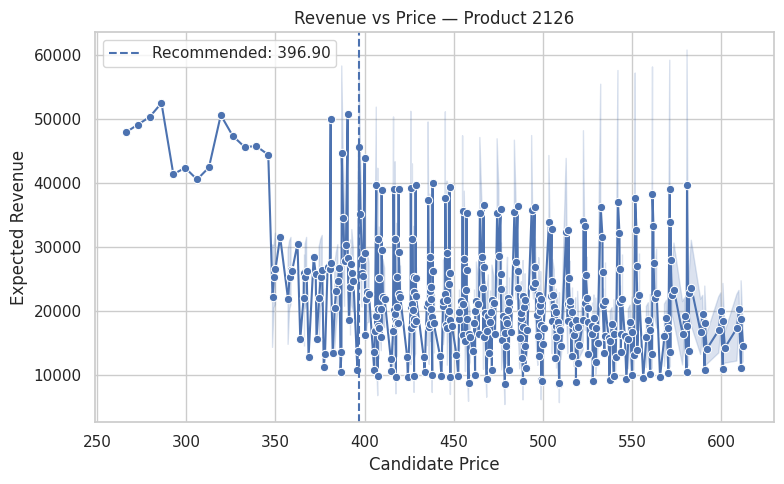

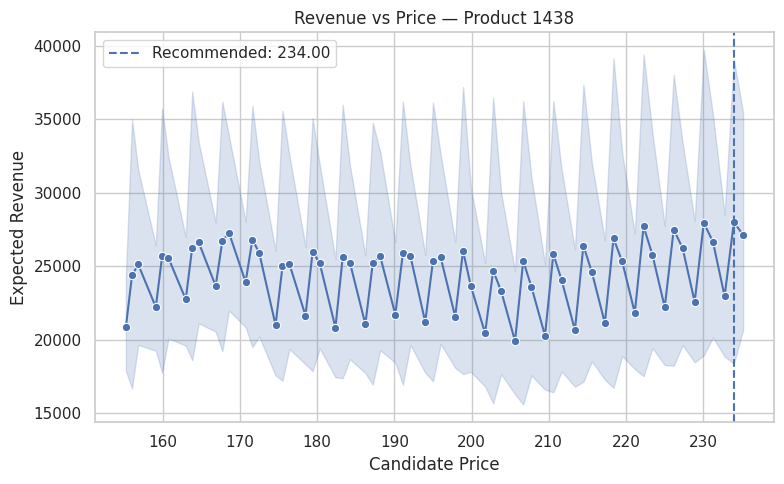

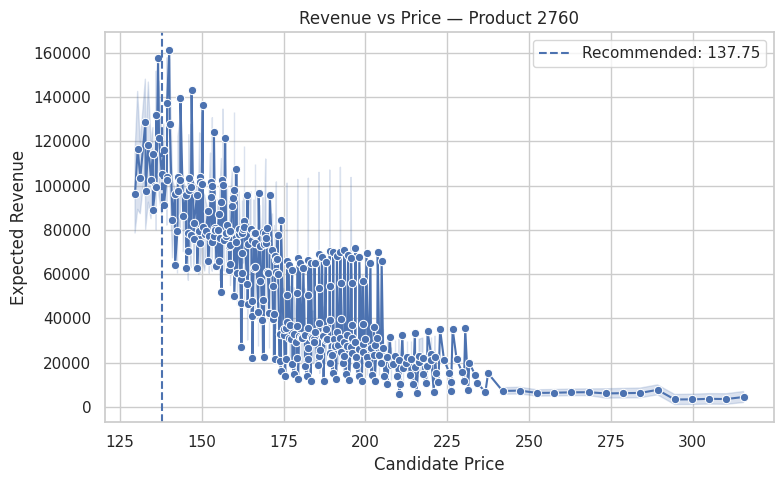

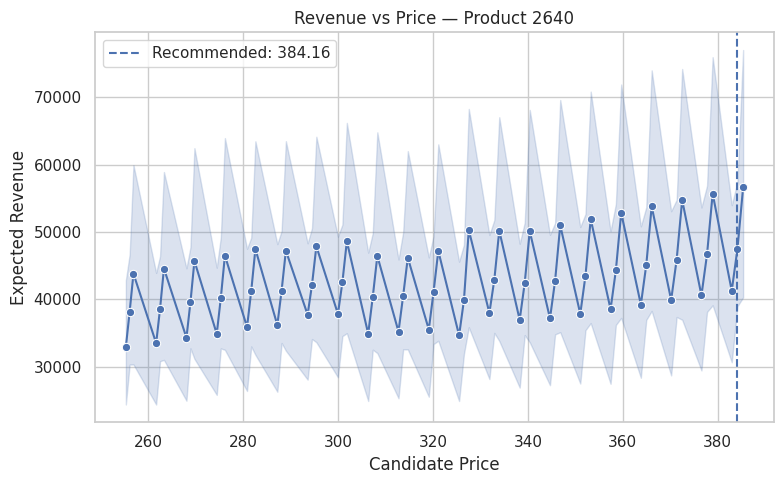

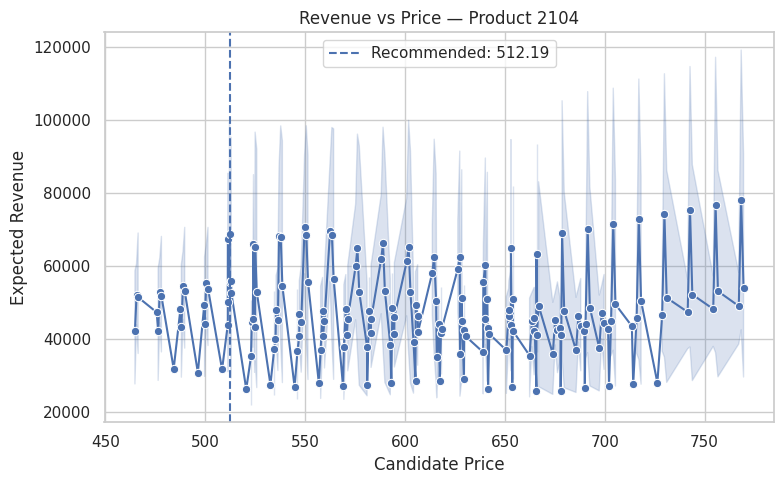

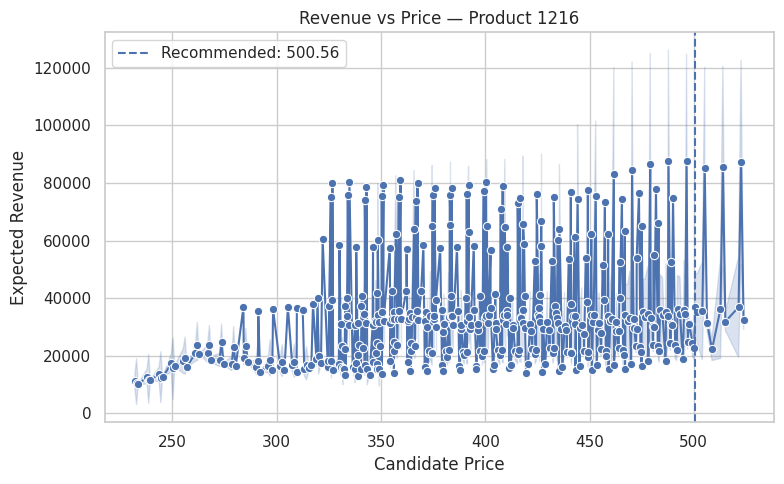

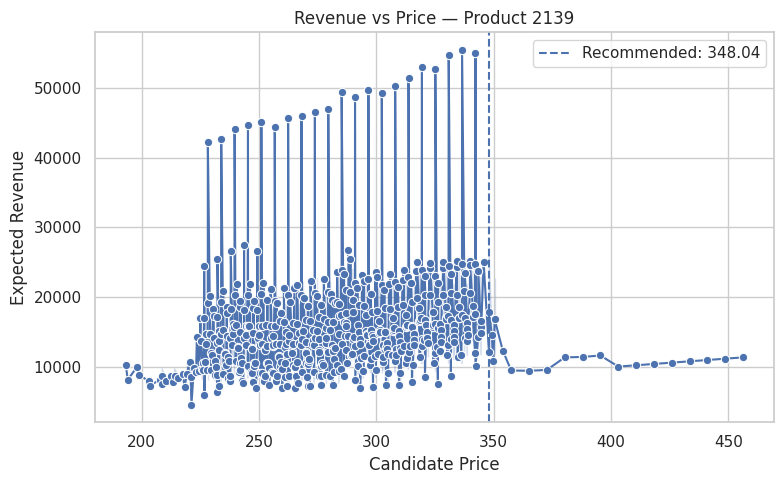

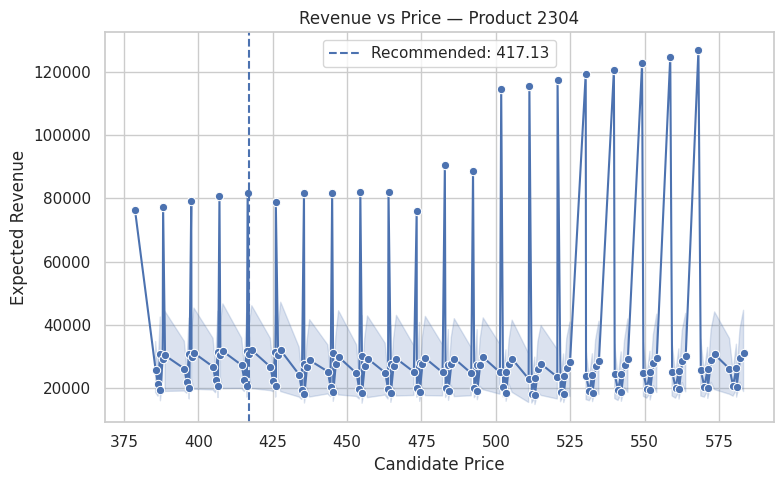

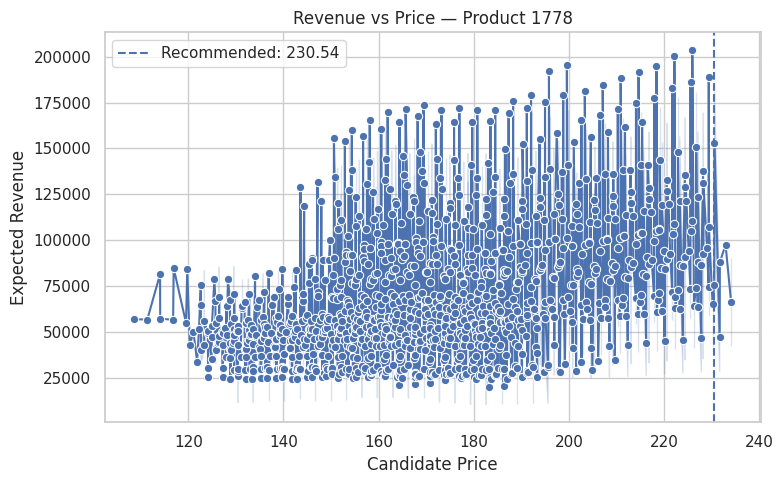

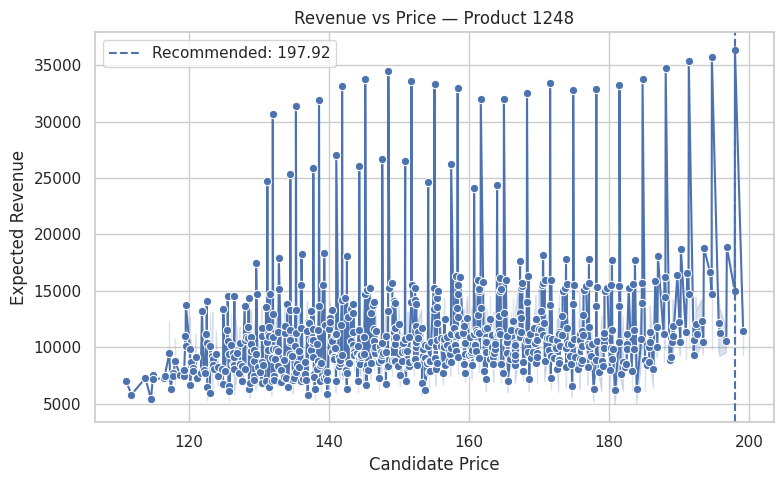

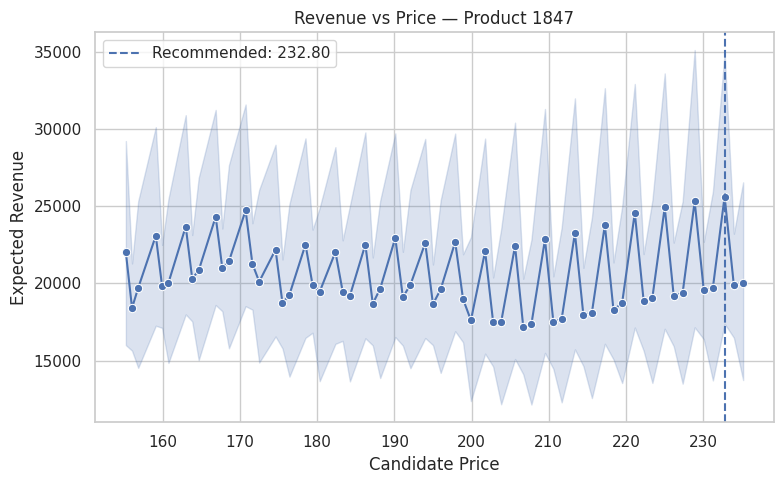

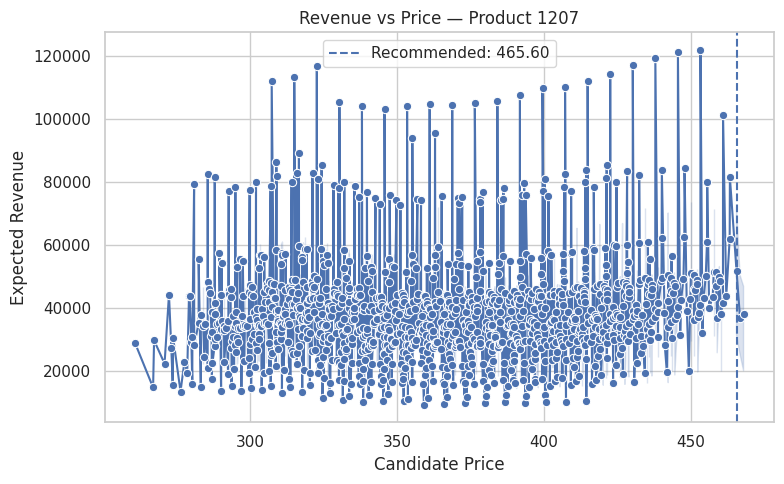

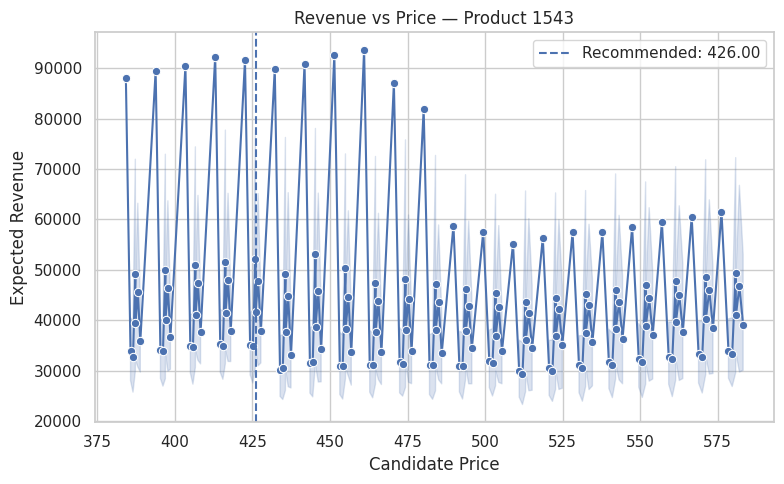

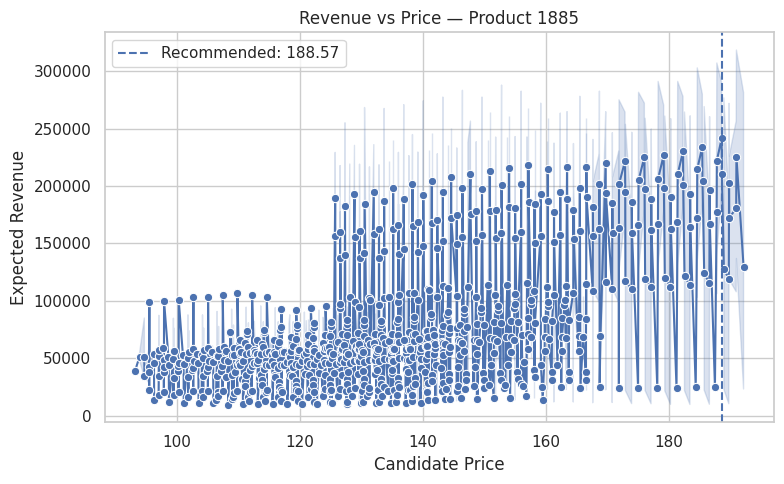

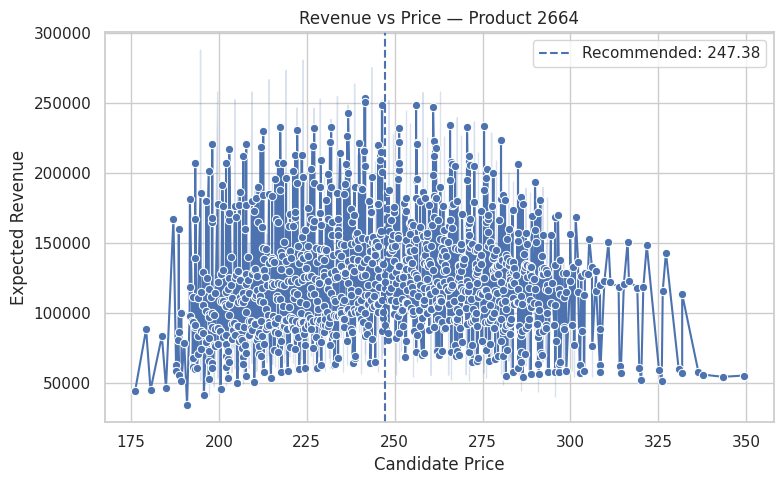

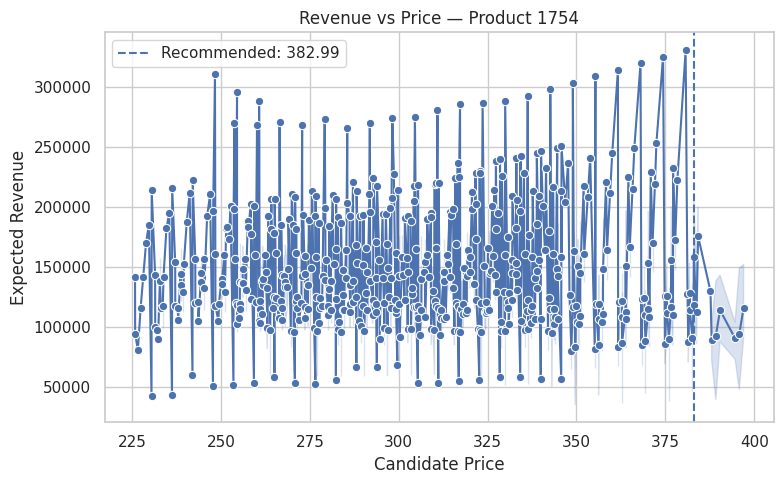

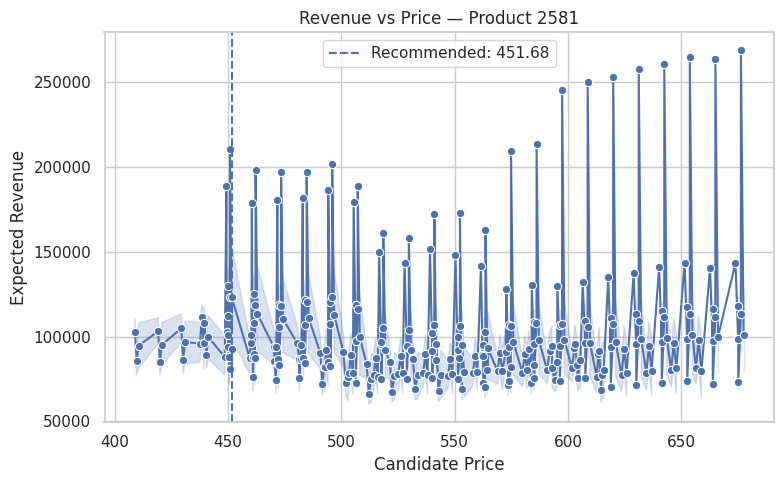

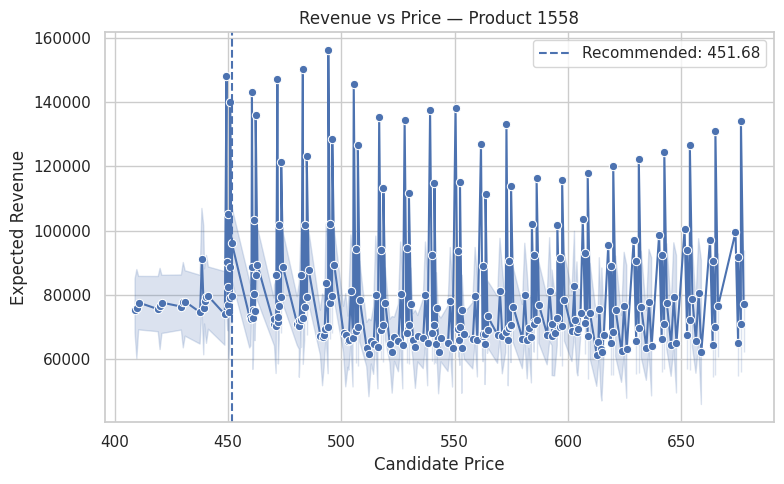

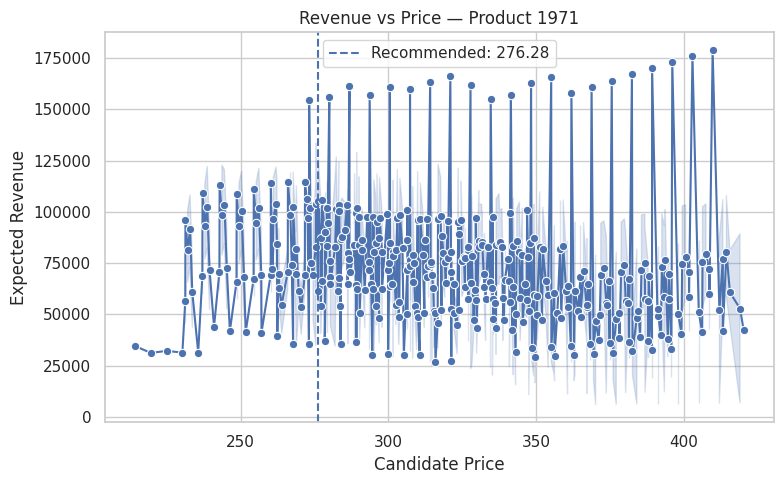

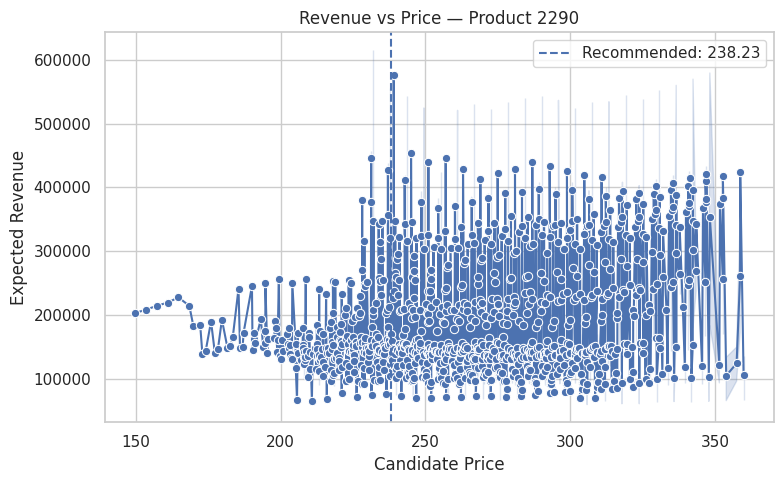

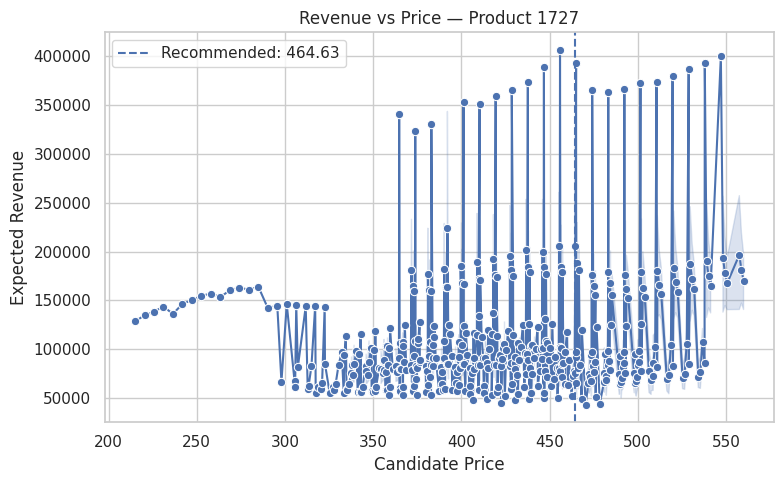

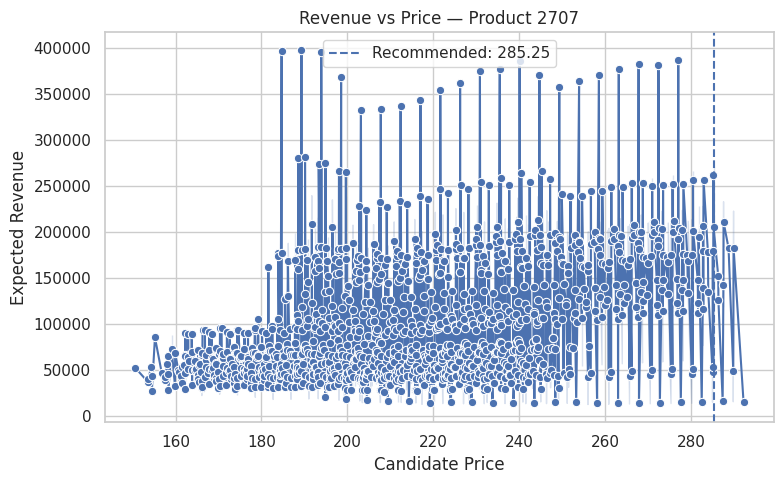

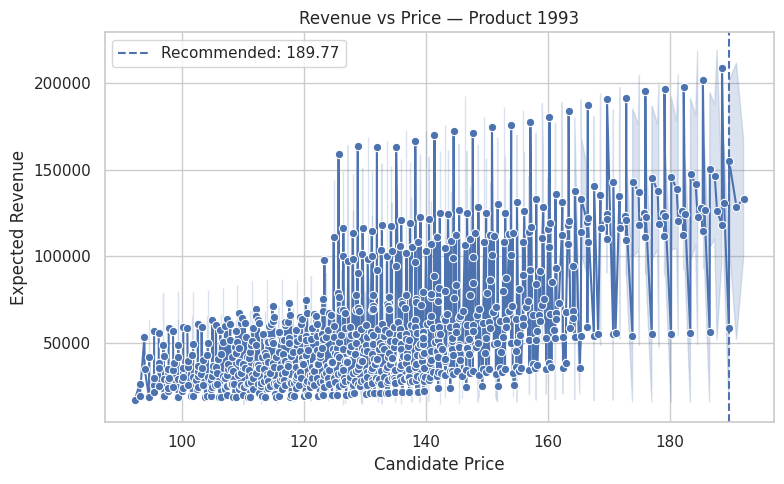

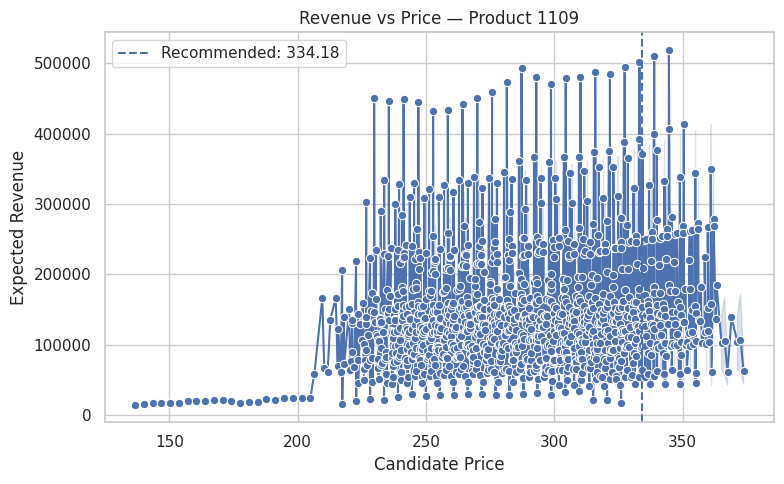

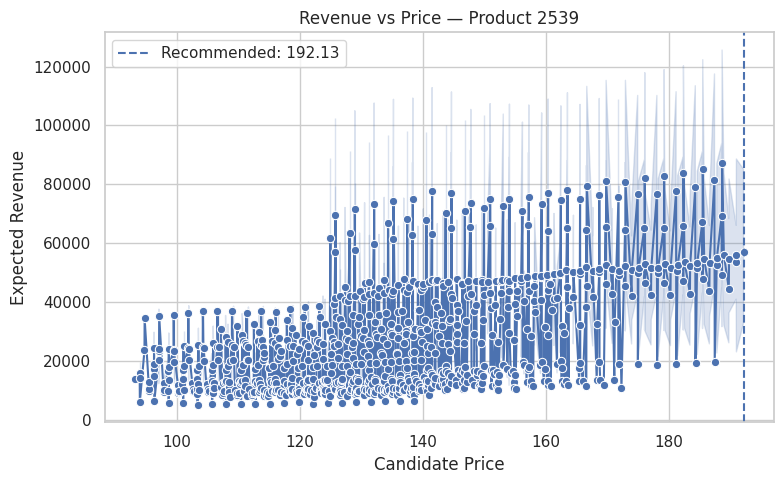

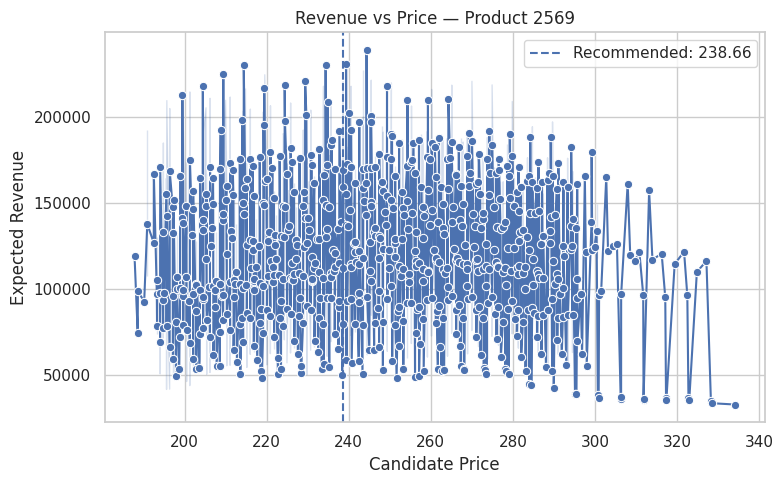

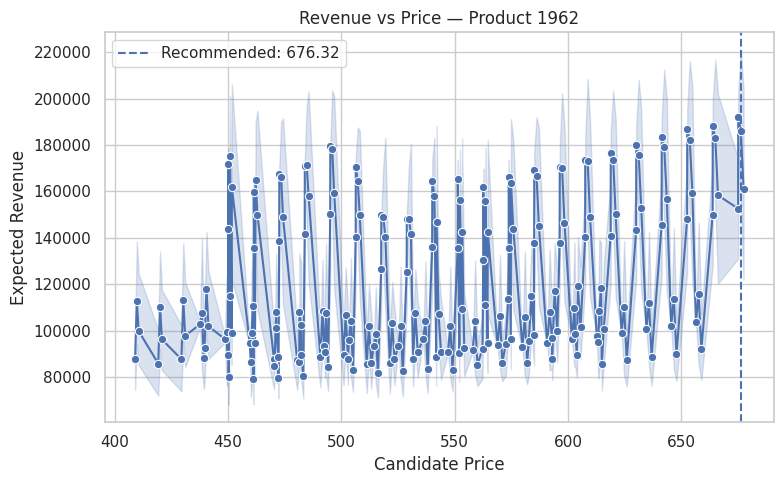

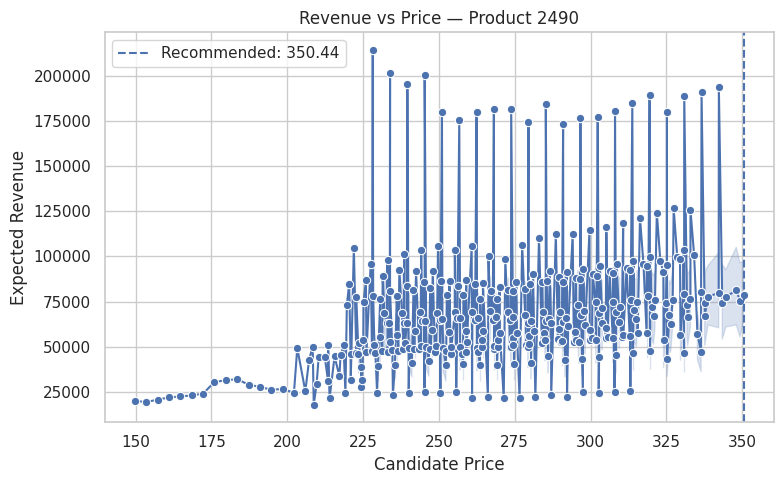

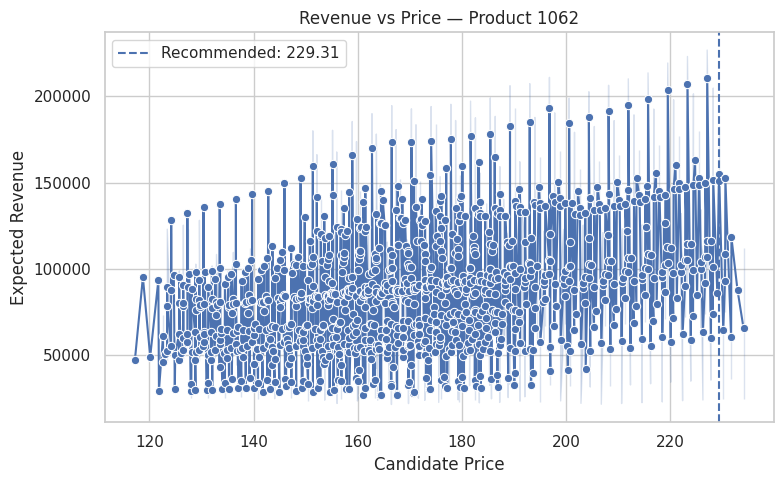

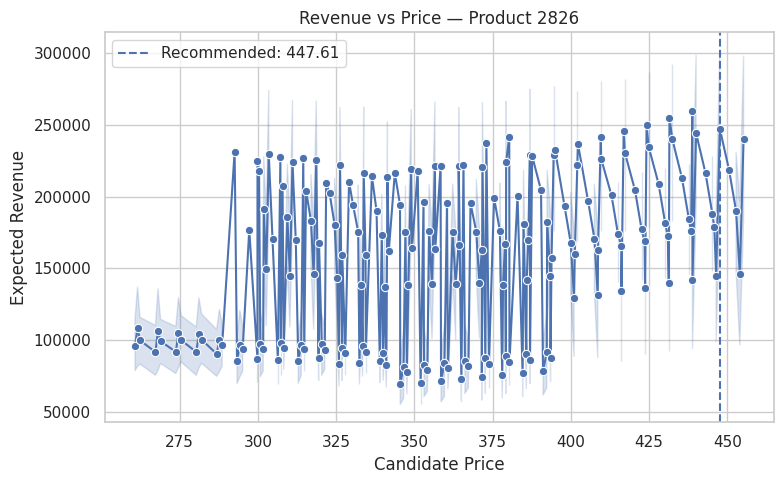

In [37]:
for product in pricing_df["ProductID"].unique():

    temp = pricing_df[pricing_df["ProductID"] == product]

    plt.figure(figsize=(8, 5))
    sns.lineplot(
        data=temp,
        x="CandidatePrice",
        y="ExpectedRevenue",
        marker="o"
    )

    best = optimal_prices[
        optimal_prices["ProductID"] == product
    ].iloc[0]

    plt.axvline(
        best["CandidatePrice"],
        linestyle="--",
        label=f"Recommended: {best['CandidatePrice']:.2f}"
    )

    plt.title(f"Revenue vs Price — Product {product}")
    plt.xlabel("Candidate Price")
    plt.ylabel("Expected Revenue")
    plt.legend()
    plt.tight_layout()
    plt.show()

# 16. Final Dynamic Pricing Recommendation

This table is the main business output.

It answers:

**What is the current price, what price does the model recommend, how much demand is expected, and what revenue is expected?**

In [38]:
# STEP 7 — Final revenue-based dynamic pricing recommendation
final_recommendation = optimal_prices[[
    "ProductID", "CurrentPrice", "CandidatePrice", "PriceChangePct",
    "PredictedDemand", "ExpectedRevenue"
]].rename(columns={"CandidatePrice": "RecommendedPrice"})

# Add elasticity information where available
if not elasticity_df.empty:
    final_recommendation = final_recommendation.merge(
        elasticity_df[["Product", "Elasticity", "Classification", "P_Value", "R2"]],
        left_on="ProductID", right_on="Product", how="left"
    ).drop(columns=["Product"])

display(final_recommendation.sort_values("ExpectedRevenue", ascending=False))


,ProductID,CurrentPrice,RecommendedPrice,PriceChangePct,PredictedDemand,ExpectedRevenue,Elasticity,Classification,P_Value,R2
48,2826,379.330000,447.6094,18.000000,6628.287598,2.966884e+06,1.323517,Positive - Investigate,2.476916e-43,0.162703
15,1727,464.630000,464.6300,0.000000,6189.979004,2.876050e+06,2.964686,Positive - Investigate,3.459422e-198,0.394437
24,1962,563.600000,676.3200,20.000000,3299.816650,2.231732e+06,-0.428558,Inelastic,5.441648e-05,0.415086
41,2581,564.600000,451.6800,-20.000000,4356.992188,1.967966e+06,-1.547768,Elastic,1.173991e-50,0.456992
16,1754,319.160000,382.9920,20.000000,4968.995117,1.903085e+06,-1.994226,Elastic,3.954805e-116,0.398299
22,1885,157.140000,188.5680,20.000000,8959.616211,1.689497e+06,2.288731,Positive - Investigate,0.000000e+00,0.238787
11,1525,321.130000,385.3560,20.000000,4120.898438,1.588013e+06,-0.357258,Inelastic,6.886075e-02,0.090814
43,2640,320.130000,384.1560,20.000000,4079.043945,1.566989e+06,-1.914639,Elastic,7.125595e-41,0.097960
26,1993,158.140000,189.7680,20.000000,8173.871094,1.551139e+06,1.574168,Positive - Investigate,3.141859e-218,0.254561
13,1558,564.600000,451.6800,-20.000000,3402.563965,1.536870e+06,-2.395189,Elastic,5.222319e-113,0.495716


# 17. Optional Profit Optimization

Revenue maximization is not always the same as profit maximization.

If product cost is available, use:

`Profit = (Price - Cost) × Predicted Demand`

If the dataset does not contain cost, **do not invent a business cost as if it were real data**. You can run a clearly labeled scenario using an assumed cost percentage.

In [39]:
# STEP 8 — Profit optimization
# IMPORTANT: the dataset does not contain actual product/meal cost.
# Therefore this is an explicit scenario assumption, not real business cost.

COST_RATIO = 0.60
pricing_df["AssumedCost"] = pricing_df["CurrentPrice"] * COST_RATIO
pricing_df["ExpectedProfit"] = (
    pricing_df["CandidatePrice"] - pricing_df["AssumedCost"]
) * pricing_df["PredictedDemand"]

product_profit_curve = (
    pricing_df
    .groupby(["ProductID", "CandidatePrice"], as_index=False)
    .agg(
        PredictedDemand=("PredictedDemand", "sum"),
        ExpectedRevenue=("ExpectedRevenue", "sum"),
        ExpectedProfit=("ExpectedProfit", "sum"),
        CurrentPrice=("CurrentPrice", "mean")
    )
)

profit_optimal = (
    product_profit_curve.loc[
        product_profit_curve.groupby("ProductID")["ExpectedProfit"].idxmax()
    ]
    .sort_values("ProductID")
    .reset_index(drop=True)
)

profit_optimal["PriceChangePct"] = (
    (profit_optimal["CandidatePrice"] - profit_optimal["CurrentPrice"])
    / profit_optimal["CurrentPrice"] * 100
)

profit_recommendation = profit_optimal[[
    "ProductID", "CurrentPrice", "CandidatePrice", "PriceChangePct",
    "PredictedDemand", "ExpectedRevenue", "ExpectedProfit"
]].rename(columns={"CandidatePrice": "ProfitMaxPrice"})

display(profit_recommendation)

print(f"NOTE: Profit results use an assumed cost ratio of {COST_RATIO:.0%}. Replace it with actual cost data if available.")


,ProductID,CurrentPrice,ProfitMaxPrice,PriceChangePct,PredictedDemand,ExpectedRevenue,ExpectedProfit
0,1062,191.09,229.3080,20.0,2029.107422,4.652906e+05,2.326453e+05
1,1109,310.43,372.5160,20.0,2014.868286,7.505707e+05,3.752853e+05
2,1198,171.75,206.1000,20.0,1352.338013,2.787169e+05,1.393584e+05
3,1207,388.00,465.6000,20.0,666.343933,3.102497e+05,1.551249e+05
4,1216,417.13,500.5560,20.0,954.844666,4.779532e+05,2.389766e+05
5,1230,359.87,431.8440,20.0,393.297760,1.698433e+05,8.492164e+04
6,1247,447.23,536.6760,20.0,729.696472,3.916106e+05,1.958053e+05
7,1248,164.93,197.9160,20.0,757.222473,1.498664e+05,7.493322e+04
8,1311,161.05,193.2600,20.0,1029.451172,1.989517e+05,9.947587e+04
9,1438,195.00,234.0000,20.0,1676.198975,3.922306e+05,1.961153e+05


NOTE: Profit results use an assumed cost ratio of 60%. Replace it with actual cost data if available.


## Final output checklist — Steps 1 to 8

- [x] Data loaded and quality checked
- [x] Data cleaned and feature engineered
- [x] EDA completed
- [x] Weekly center × product dataset created
- [x] Price variation checked
- [x] Historical demand / lag / rolling features created without target leakage
- [x] Controlled price elasticity estimated
- [x] Chronological train/test split used
- [x] Linear Regression, Random Forest and XGBoost compared
- [x] R² and Adjusted R² reported
- [x] XGBoost feature importance analyzed
- [x] Residual analysis completed
- [x] Tuned XGBoost trained and compared with original XGBoost
- [x] Best model selected using out-of-sample RMSE/MAE
- [x] Actual vs predicted demand checked
- [x] Price simulation completed
- [x] Revenue-maximizing price identified
- [x] Final dynamic pricing recommendation generated
- [x] Optional profit optimization included with an explicit cost assumption

**Important:** The adjusted R² shown for one-hot encoded tree/boosting models is supplementary, not a proof of model quality. For the final project, prioritize out-of-sample RMSE, MAE and R².

# STEP 8 — Project conclusion
print("Project pipeline completed:")
print("1. Improved pricing features")
print("2. Leakage-safe lag and rolling demand features")
print("3. Observational price elasticity")
print("4. Strict time-based demand prediction")
print("5. Model comparison and best-model selection")
print("6. Candidate-price simulation")
print("7. Revenue-maximizing dynamic price")
print("8. Scenario-based profit optimization")

print("\nFinal business logic:")
print("Current Price → Candidate Prices → Predicted Demand → Revenue/Profit → Recommended Price")

print("\nImportant: elasticity is estimated from observational historical data and should not automatically be interpreted as causal.")
